<div style="
    background: linear-gradient(90deg, #1a73e8 0%, #ffffff 100%);
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h2 style="color: white; margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    🧠 Asignatura : Computación Bioinspirada
  </h2>
</div>


# Lógica Difusa y Algoritmos de Adaptación Social

- **Fecha**      : 10-03-2026
- **Grupo No.**  : 2

# Autores
- Sánchez Mendieta Juan Pablo
- Rodríguez Vélez Ximena Jhoana
- Viteri Ayala Flavia Kamila

# Estructura del notebook
1. **SECCIÓN 1** : Experimentación con lógica difusa: Control de derrape vehicular
2. **SECCIÓN 2** :Experimentación con lógica difusa: Aplicación en entorno de trabajo
3. **SECCIÓN 3**: Experimentación con algoritmo PSO

<div style="
    background: linear-gradient(90deg, #1a73e8 0%, #ffffff 100%);
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h2 style="color: white; margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    🚀 SECCIÓN 1: Experimentación con lógica difusa: Control de derrape vehicular
  </h2>
</div>

# Descripción del problema
Conducir en un día lluvioso puede ser peligroso, en caso de derrapar se debe mantener
la calma y evitar movimientos bruscos. Si derrapa, puede ayudar soltar el acelerador,
pisar suavemente el freno si es necesario, y girar el volante en la dirección opuesta
a la del derrape. Si el derrape es leve, puede corregirlo con movimientos suaves del volante.

# Sistemas a modelar

| Caso           | Tipo de tracción    | Descripción de la corrección del derrape                                                                                                |
|:---------------|:--------------------|:----------------------------------------------------------------------------------------------------------------------------------------|
| **Caso A**     | FWD (Tracción Delantera) | El motor arrastra las ruedas delanteras; el derrape se corrige girando el volante en la dirección del derrape y soltando gradualmente el acelerador. |
| **Caso B**     | RWD (Tracción Trasera)   | El motor empuja desde atrás; el derrape trasero se corrige contra-girando el volante (opuesto al derrape) con liberación de gas más agresiva.    |  

# Universos de discurso

| Tipo        | Variable             | Rango       | Variables Lingüísticas                                   | Descripción                                         |
|:------------|:---------------------|:------------|:---------------------------------------------------------|:----------------------------------------------------|
| **Entrada** | `intensidad_derrape` | `[0, 10]`   | Leve, Medio, Fuerte                                      | Qué tan severo es el derrape                        |
| **Entrada** | `velocidad_angular`  | `[0, 10]`   | Baja, Media, Alta                                        | Yaw rate (rotación del chasis)                      |
| **Salida**  | `correccion_volante` | `[-10, 10]` | Izq. Fuerte, Izq. Suave, Neutro, Der. Suave, Der. Fuerte | Ángulo de corrección (neg=izq, pos=der)             |
| **Salida**  | `frenado`            | `[0, 10]`   | Ninguno, Suave, Fuerte                                   | Intensidad de frenado asistido                      |
| **Salida**  | `aceleracion`        | `[0, 10]`   | Ninguno, Suave, Fuerte                                   | Intensidad de aceleración  

# Objetivo del sistema
Diseñar y experimentar con un sistema de inferencia de lógica difusa para el control de derrapes vehiculares. Este sistema busca determinar las acciones de corrección del volante, frenado y aceleración necesarias, basándose en la intensidad del derrape y la velocidad angular del vehículo, y adaptándose a dos tipos de tracción (FWD y RWD).


# Configuración de librerías

In [ ]:
# ==============================================================
# Librerías y configuración
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations

# Reproducibilidad
np.random.seed(42) # Reproducibilidad de resultados aleatorios

# Estilo de gráficos
plt.rcParams.update({
    "figure.dpi": 110,    # Resolución de la figura
    "axes.grid": True,    # Cuadrícula activada
    "grid.alpha": 0.3,    # Cuadrícula semitransparente
    "font.size": 10,
})

print("Configuración ejecutada.")

Configuración ejecutada.


# Definición de funciones de pertenencia

In [ ]:
# =================================================================================
# Funciones de membresía/pertenencia (MF)
#
# Se crean las funciones de membresía (MF) que van a asignar un
# valor (grado de pertenencia) μ ∈ [0, 1] al un conjunto
# lingüístico que definiremos (p.ej. "leve", "fuerte").

# Se implementan dos formas canónicas:
#   - Triangular (trimf): útil para categorías intermedias con pico bien definido.
#   - Trapezoidal (trapmf): útil para categorías extremas con zona plana (μ = 1).
# =================================================================================

def trimf(x: np.ndarray, a: float, b: float, c: float) -> np.ndarray:
    """
    Función de membresía TRIANGULAR.

    Parámetros
    ---------------
    x : array de valores de entrada (universo de discurso)
    a : punto donde la función empieza a subir (μ = 0 para x ≤ a)
    b : punto pico donde μ = 1
    c : punto donde la función termina de bajar (μ = 0 para x ≥ c)

    Retorna
    ---------------
    Array de valores μ ∈ [0, 1] para cada elemento de x

    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    # Rama izquierda (pendiente positiva)
    mask_left = (a < x) & (x <= b)
    y[mask_left] = (x[mask_left] - a) / (b - a)

    # Rama derecha (pendiente negativa)
    mask_right = (b < x) & (x < c)
    y[mask_right] = (c - x[mask_right]) / (c - b)
    return y


def trapmf(x: np.ndarray, a: float, b: float, c: float, d: float) -> np.ndarray:
    """
    Función de membresía TRAPEZOIDAL.

    Permite modelar categorías extremas ("muy leve" o "muy
    fuerte") donde un rango completo de valores merece membresía máxima,
    evitando la rigidez de un único pico triangular.

     Parámetros
    ---------------
    x : array de valores de entrada (universo de discurso)
    a : inicio del flanco izquierdo (μ pasa de 0 a 1 entre a y b)
    b : inicio de la zona plana (μ = 1 entre b y c)
    c : fin de la zona plana
    d : fin del flanco derecho (μ pasa de 1 a 0 entre c y d)

    Retorna
    ---------------
    Array de valores μ ∈ [0, 1]

    """
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    mask_left  = (a < x) & (x <= b)
    mask_flat  = (b < x) & (x <= c)
    mask_right = (c < x) & (x < d)
    if b > a:
        y[mask_left]  = (x[mask_left]  - a) / (b - a)
    y[mask_flat]  = 1.0
    if d > c:
        y[mask_right] = (d - x[mask_right]) / (d - c)
    return y


def centroid_defuzz(universe: np.ndarray, aggregated_mf: np.ndarray) -> float:
    """
    Defuzzificación por CENTROIDE (Centro de Gravedad).

    Calcular el punto del eje x que representa el "centro de masa" del
    conjunto difuso agregado.

    Este método pondera todas las reglas activas de forma proporcional
    a su área, produciendo salidas suaves y continuas ante pequeños
    cambios en las entradas.

    Fórmula:
        x* = ∫ μ(x)·x dx  /  ∫ μ(x) dx

    Si el denominador es 0 (ninguna regla activa), se devuelve el punto medio
    del universo como valor neutro.

    """
    num   = np.trapezoid(aggregated_mf * universe, universe)
    denom = np.trapezoid(aggregated_mf, universe)
    if denom == 0:
        return float(np.mean(universe))
    return float(num / denom)


def plot_mf(universe, mf_dict, title, xlabel, ylabel="Grado de membresía μ"):
    """
    Visualización gráfica de múltiples funciones de membresía sobre un mismo
    universo de discurso.

    Permite verificar que los conjuntos lingüísticos se solapan correctamente
    y cubren todo el universo sin zonas muertas.

    """
    fig, ax = plt.subplots(figsize=(9, 3.5))
    for label, values in mf_dict.items():
        ax.plot(universe, values, label=label, linewidth=1.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

print("Funciones auxiliares definidas: trimf, trapmf, centroid_defuzz, plot_mf.")

Funciones auxiliares definidas: trimf, trapmf, centroid_defuzz, plot_mf.


# Definición de los universos de discurso

In [ ]:
# =================================================================================
# PASO 1: Definir universos de discurso
#
# Se establece el rango de valores numéricos que cada variable de nuestro
# sistema de control difuso puede tomar.
#
# Para cada variable, se utiliza la función np.linspace(inicio, fin, num_puntos),
# lo que genera una secuencia de num_puntos igualmente espaciados entre inicio y
# fin (inclusive). Al usar 1000 puntos, aseguramos una alta resolución para las
# funciones de membresía y los cálculos de defuzzificación, sin un costo
# computacional significativo.
#
# Derrape: Los valores van de 0 (sin derrape) a 10 (derrape máximo).
#
# Velocidad angular (yaw rate): Los valores van de `0` (sin rotación del chasis)
# a `10` (rotación máxima).
#
# Corrección del volante: Los valores negativos (`-10` a `0`) indican giros a
# la izquierda, y los valores positivos (`0` a `10`) indican giros a la derecha.
# El `0` representa no aplicar corrección.
#
# Frenado: Los valores van de 0 (sin frenado) a 10 (frenado máximo).
#
# Aceleración: Los valores van de 0 (sin aceleración) a 10 (aceleración máxima).
# =================================================================================

u_derrape   = np.linspace(0, 10, 1000)   # intensidad del derrape
u_vel_ang   = np.linspace(0, 10, 1000)   # velocidad angular (yaw rate)
u_volante   = np.linspace(-10, 10, 1000) # corrección de volante (negativo=izq, positivo=der)
u_frenado   = np.linspace(0, 10, 1000)   # intensidad de frenado
u_aceleracion = np.linspace(0, 10, 1000)   # intensidad de aceleración

print("PASO 1: Definir universos de discurso - Ejecutado")

PASO 1: Definir universos de discurso - Ejecutado


# Crear variables lingüísticas (antecedentes y consecuentes) y asignación de funciones de pertenecia

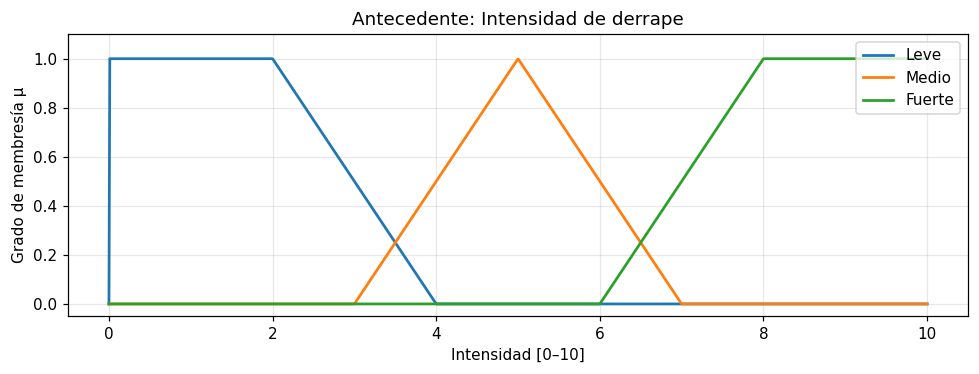


[Resultado] Antecedente 1 — Intensidad de derrape

Se definen tres conjuntos lingüísticos sobre el universo [0, 10]:

  • Leve   (trapezoidal): μ=1 en [0,2], decae a 0 en x=4. Modela situaciones donde el vehículo apenas pierde adherencia.
  • Medio  (triangular) : pico en x = 5, activo entre [3, 7]. Representa un derrape perceptible pero aún controlable.
  • Fuerte (trapezoidal): sube de 0 a 1 entre [6, 8] y se mantiene en μ = 1 hasta x = 10. Captura situaciones críticas de pérdida de control.

  Los conjuntos se solapan en los rangos [2, 4] y [6, 8], lo que
  garantiza transiciones suaves: ante un valor intermedio (p.ej. derrape = 3.5), el sistema activa
  parcialmente tanto "Leve" como "Medio", produciendo una respuesta graduada en lugar de un salto brusco.




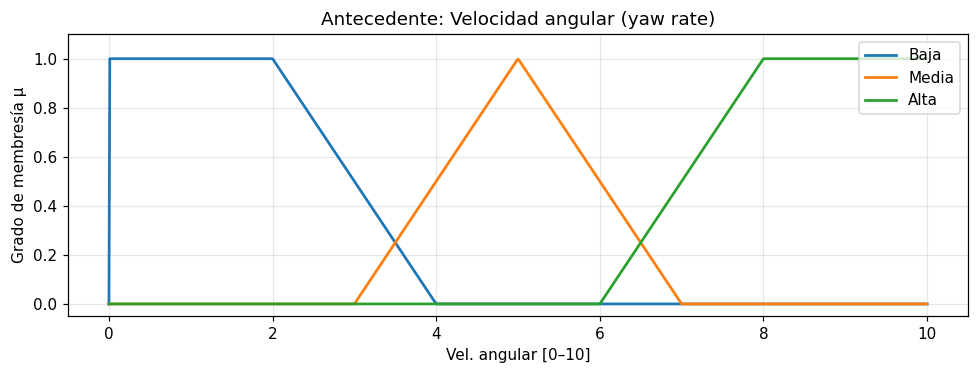


[Resultado] Antecedente 2 — Velocidad angular (yaw rate)

Estructura idéntica al antecedente 1 (Baja / Media / Alta) con los mismos
puntos de corte, ya que ambas variables comparten la misma escala [0,10]
y el mismo comportamiento cualitativo.

Ambas variables comparten la misma escala normalizada y el mismo comportamiento
cualitativo (de ninguna a máxima intensidad), por lo que reutilizar la misma
partición lingüística es coherente y simplifica el diseño de reglas.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de
las reglas: "IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente
interpretable porque los conjuntos tienen la misma semántica.




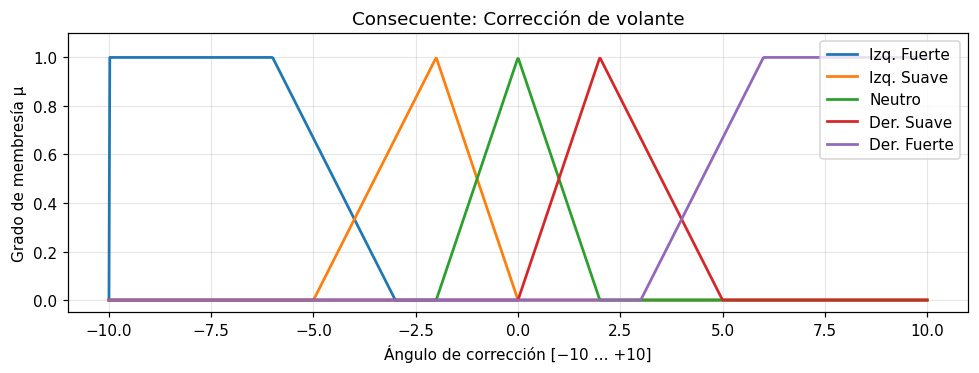


[Resultado] Consecuente 1 — Corrección de volante

Cinco conjuntos lingüísticos sobre el universo [−10, +10]:

- Izq. Fuerte (trapezoidal): μ = 1 en [−10, −6], decae hasta −3. Corrección máxima hacia la izquierda.
- Izq. Suave (triangular): pico en x = −2, activo en [−5, 0].
- Neutro (triangular): pico en x = 0, activo en [−2, 2]. Sin corrección.
- Der. Suave (triangular): pico en x = 2, activo en [0, 5].
- Der. Fuerte (trapezoidal): sube en [3, 6], μ = 1 en [6, 10]. Corrección máxima hacia la derecha.

Se utilizan 5 conjuntos porque a diferencia de las variables de intensidad (que solo necesitan magnitud),
el volante tiene dirección, por lo tanto, se necesita representar tanto el sentido (izquierda/derecha)
como la magnitud (suave/fuerte), además del estado neutro, lo que justifica la mayor granularidad.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de las reglas:
"IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente interpretable porque 

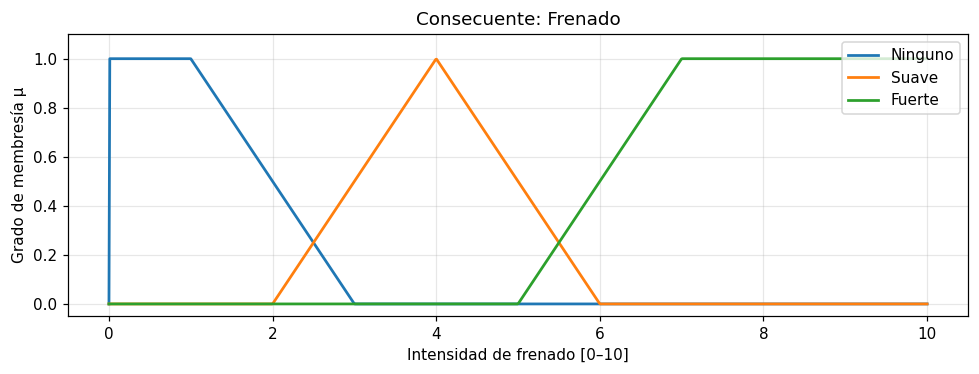


[Resultado] Consecuente 2 — Intensidad de frenado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplicar freno.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Frenado moderado.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Frenado de emergencia.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia
  la regla "IF derrape=Leve THEN frenado=Ninguno" debe poder activar una MF
  concreta. Si no existiera este conjunto, un derrape leve no generaría ninguna
  salida de frenado y el centroide podría desplazarse incorrectamente.




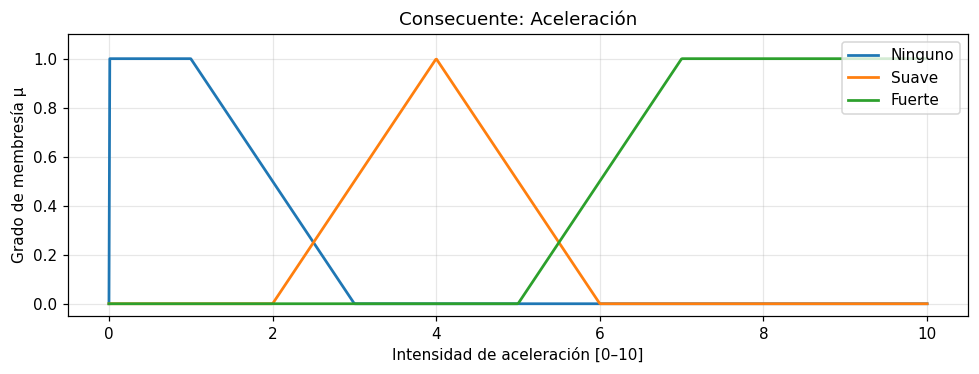


[Resultado] Consecuente 3 — Intensidad de acelerado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplica aceleración.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Aceleración parcial.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Aceleración total.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia
  la regla "IF derrape=Leve THEN aceleracion=Ninguno" debe poder activar una MF
  concreta. Si este conjunto existe, quiere decir que se pierde totalmente el control.


PASO 2: Definir funciones de pertenencia y conjuntos linguisticos - Ejecutado


In [ ]:
# =================================================================================
# PASO 2: Definir funciones de pertenencia y conjuntos linguisticos
#
# A cada universo se le asignan 3–5 conjuntos lingüísticos que lo cubren.
#
# Función trapezoidal: Los valores muy bajos o muy altos merecen
# membresía máxima en un rango (no solo en un pico), por eso se usa trapmf.
#
# Función triangular en el centro: La categoría media tiene un pico definido
# y decrece simétricamente a ambos lados.
# =================================================================================

# ─── Antecedente 1: Intensidad de derrape ────────────────────────────────────
mf_der_leve   = trapmf(u_derrape, 0, 0, 2, 4)
mf_der_medio  = trimf(u_derrape,  3, 5, 7)
mf_der_fuerte = trapmf(u_derrape, 6, 8, 10, 10)

plot_mf(u_derrape,
        {"Leve": mf_der_leve, "Medio": mf_der_medio, "Fuerte": mf_der_fuerte},
        "Antecedente: Intensidad de derrape",
        "Intensidad [0–10]")

print("""
[Resultado] Antecedente 1 — Intensidad de derrape

Se definen tres conjuntos lingüísticos sobre el universo [0, 10]:

  • Leve   (trapezoidal): μ=1 en [0,2], decae a 0 en x=4. Modela situaciones donde el vehículo apenas pierde adherencia.
  • Medio  (triangular) : pico en x = 5, activo entre [3, 7]. Representa un derrape perceptible pero aún controlable.
  • Fuerte (trapezoidal): sube de 0 a 1 entre [6, 8] y se mantiene en μ = 1 hasta x = 10. Captura situaciones críticas de pérdida de control.

  Los conjuntos se solapan en los rangos [2, 4] y [6, 8], lo que
  garantiza transiciones suaves: ante un valor intermedio (p.ej. derrape = 3.5), el sistema activa
  parcialmente tanto "Leve" como "Medio", produciendo una respuesta graduada en lugar de un salto brusco.

""")

# ─── Antecedente 2: Velocidad angular (yaw rate) ─────────────────────────────
# La velocidad angular indica cuán rápido rota el chasis.
# Un yaw rate alto con derrape fuerte es la situación más peligrosa.
mf_va_baja  = trapmf(u_vel_ang, 0, 0, 2, 4)
mf_va_media = trimf(u_vel_ang,  3, 5, 7)
mf_va_alta  = trapmf(u_vel_ang, 6, 8, 10, 10)

plot_mf(u_vel_ang,
        {"Baja": mf_va_baja, "Media": mf_va_media, "Alta": mf_va_alta},
        "Antecedente: Velocidad angular (yaw rate)",
        "Vel. angular [0–10]")

print("""
[Resultado] Antecedente 2 — Velocidad angular (yaw rate)

Estructura idéntica al antecedente 1 (Baja / Media / Alta) con los mismos
puntos de corte, ya que ambas variables comparten la misma escala [0,10]
y el mismo comportamiento cualitativo.

Ambas variables comparten la misma escala normalizada y el mismo comportamiento
cualitativo (de ninguna a máxima intensidad), por lo que reutilizar la misma
partición lingüística es coherente y simplifica el diseño de reglas.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de
las reglas: "IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente
interpretable porque los conjuntos tienen la misma semántica.

""")

# ─── Consecuente 1: Corrección de volante ────────────────────────────────────
# Se aplican 5 conjuntos porque la corrección de volante tiene dirección (izq/der)
# y magnitud (suave/fuerte), más un estado neutro → requiere mayor granularidad.
# Positivo = girar hacia la derecha, negativo = hacia la izquierda.
mf_vol_izq_fuerte = trapmf(u_volante, -10, -10, -6, -3)
mf_vol_izq_suave  = trimf(u_volante,  -5,  -2,  0)
mf_vol_neutro     = trimf(u_volante,  -2,   0,  2)
mf_vol_der_suave  = trimf(u_volante,   0,   2,  5)
mf_vol_der_fuerte = trapmf(u_volante,  3,   6,  10, 10)

plot_mf(u_volante,
        {"Izq. Fuerte": mf_vol_izq_fuerte, "Izq. Suave": mf_vol_izq_suave,
         "Neutro": mf_vol_neutro,
         "Der. Suave": mf_vol_der_suave, "Der. Fuerte": mf_vol_der_fuerte},
        "Consecuente: Corrección de volante",
        "Ángulo de corrección [−10 … +10]")

print("""
[Resultado] Consecuente 1 — Corrección de volante

Cinco conjuntos lingüísticos sobre el universo [−10, +10]:

- Izq. Fuerte (trapezoidal): μ = 1 en [−10, −6], decae hasta −3. Corrección máxima hacia la izquierda.
- Izq. Suave (triangular): pico en x = −2, activo en [−5, 0].
- Neutro (triangular): pico en x = 0, activo en [−2, 2]. Sin corrección.
- Der. Suave (triangular): pico en x = 2, activo en [0, 5].
- Der. Fuerte (trapezoidal): sube en [3, 6], μ = 1 en [6, 10]. Corrección máxima hacia la derecha.

Se utilizan 5 conjuntos porque a diferencia de las variables de intensidad (que solo necesitan magnitud),
el volante tiene dirección, por lo tanto, se necesita representar tanto el sentido (izquierda/derecha)
como la magnitud (suave/fuerte), además del estado neutro, lo que justifica la mayor granularidad.

Resultado: La simetría entre las dos gráficas de antecedentes facilita la lectura de las reglas:
"IF derrape = Fuerte AND vel_angular = Alta" es inmediatamente interpretable porque los conjuntos
tienen la misma semántica.

""")

# ─── Consecuente 2: Intensidad de frenado ────────────────────────────────────
# Se incluye frenado porque en derrapes severos reducir velocidad es esencial.
# En RWD, frenar agresivamente en derrape medio puede empeorar el sobreviraje.
mf_freno_ninguno = trapmf(u_frenado, 0, 0, 1, 3)
mf_freno_suave   = trimf(u_frenado,  2, 4, 6)
mf_freno_fuerte  = trapmf(u_frenado, 5, 7, 10, 10)

plot_mf(u_frenado,
        {"Ninguno": mf_freno_ninguno, "Suave": mf_freno_suave, "Fuerte": mf_freno_fuerte},
        "Consecuente: Frenado",
        "Intensidad de frenado [0–10]")

print("""
[Resultado] Consecuente 2 — Intensidad de frenado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplicar freno.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Frenado moderado.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Frenado de emergencia.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia
  la regla "IF derrape=Leve THEN frenado=Ninguno" debe poder activar una MF
  concreta. Si no existiera este conjunto, un derrape leve no generaría ninguna
  salida de frenado y el centroide podría desplazarse incorrectamente.

""")

# ─── Consecuente 3: Intensidad de aceleración ────────────────────────────────────
# Se incluye aceleración porque en derrapes es importante maniobrar la aceleración para
# dejar de aceleración.

mf_aceleracion_ninguno = trapmf(u_aceleracion, 0, 0, 1, 3)
mf_aceleracion_suave   = trimf(u_aceleracion,  2, 4, 6)
mf_aceleracion_fuerte  = trapmf(u_aceleracion, 5, 7, 10, 10)

plot_mf(u_aceleracion,
        {"Ninguno": mf_aceleracion_ninguno, "Suave": mf_aceleracion_suave, "Fuerte": mf_aceleracion_fuerte},
        "Consecuente: Aceleración",
        "Intensidad de aceleración [0–10]")

print("""
[Resultado] Consecuente 3 — Intensidad de acelerado

Tres conjuntos sobre [0, 10]:

  • Ninguno (trapezoidal): μ=1 en [0,1], decae a 0 en x=3. No aplica aceleración.
  • Suave   (triangular) : pico en x=4, activo en [2,6]. Aceleración parcial.
  • Fuerte  (trapezoidal): sube en [5,7], μ=1 en [7,10]. Aceleración total.

  "Ninguno" existe como conjunto explícito porque en el motor de inferencia
  la regla "IF derrape=Leve THEN aceleracion=Ninguno" debe poder activar una MF
  concreta. Si este conjunto existe, quiere decir que se pierde totalmente el control.

""")


print("PASO 2: Definir funciones de pertenencia y conjuntos linguisticos - Ejecutado")

# Definición reglas difusas e mplementacion del sistema de control difuso

Todos los universos en este diseño están completamente cubiertos (no hay zonas donde ningún conjunto tenga μ > 0),
los solapamientos son adecuados (~30–40% de superposición entre conjuntos adyacentes), y las formas trapezoidales
en los extremos evitan que valores fuera del rango esperado queden sin representación.

In [ ]:
# =================================================================================
# PASO 3: Sistema de control difuso
#
# Flujo interno:
#
# 1. Fuzzificación
# 2. Definición de reglas difusas
# 3. Agregación
# 4. Defuzzificación
# =================================================================================

def infer_skid_control(derrape_val: float, vel_ang_val: float, mode: str = "FWD") -> dict:
    """
    Sistema de control difuso para derrape vehicular.

    Parámetros
    ----------
    derrape_val : float — intensidad de derrape [0, 10]
    vel_ang_val : float — velocidad angular [0, 10]
    mode        : str   — 'FWD' (tracción delantera) | 'RWD' (tracción trasera)

    Retorna
    -------
    dict con los valores nítidos defuzzificados: correccion_volante, frenado

    Flujo interno
    -------
      1. Fuzzificación   → interpolar μ de cada entrada en sus MF
      2. Evaluación de reglas → AND = min(), OR = max()
      3. Agregación      → cortar MF de salida con np.fmin, unir con np.fmax
      4. Defuzzificación → centroide sobre el conjunto agregado

    """
    # ─── 1. Fuzzificación: Calcular μ para cada valor de entrada ───────────────────
    # np.interp evalúa el grado de membresía del valor de entrada en cada
    # función de membresía previamente definida.
    # Las MF ya están muestreadas en el universo;
    # interpolar es más eficiente y evita duplicar código.

    mu_der = {
        "leve":   float(np.interp(derrape_val,  u_derrape,  mf_der_leve)),
        "medio":  float(np.interp(derrape_val,  u_derrape,  mf_der_medio)),
        "fuerte": float(np.interp(derrape_val,  u_derrape,  mf_der_fuerte)),
    }
    mu_va = {
        "baja":  float(np.interp(vel_ang_val, u_vel_ang, mf_va_baja)),
        "media": float(np.interp(vel_ang_val, u_vel_ang, mf_va_media)),
        "alta":  float(np.interp(vel_ang_val, u_vel_ang, mf_va_alta)),
    }

    # ─── 2. Definición de reglas difusas ───────────────────
    # Cada regla es de la forma IF (A AND B) THEN C.
    #   AND  → mínimo de los grados de membresía (t-norma)
    #   OR   → máximo de los grados de membresía (s-norma)
    #
    # Se usan reglas distintas por modo:
    #   FWD → la corrección es en la MISMA dirección del derrape (por convenio,
    #         asumimos derrape hacia la derecha → girar a la derecha).
    #   RWD → la corrección es en la dirección OPUESTA (contra-dirección),
    #         y el frenado en derrape medio se omite porque empeora el sobreviraje.


    # CASO A - Tracción delantera (FWD): Girar en dirección del derrape (misma dirección)
    # El derrape se asume "hacia la derecha" como positivo.
    if mode == "FWD":
        rules_volante = {
            # Leve → corrección suave a la derecha
            "der_suave":  min(mu_der["leve"],   mu_va["baja"]),
            # Medio + media VA → corrección moderada
            "der_fuerte": max(min(mu_der["medio"],  mu_va["media"]),
                              min(mu_der["fuerte"], mu_va["alta"])),
            # Si derrape fuerte pero baja velocidad → neutro (cuidado)
            "neutro":     min(mu_der["fuerte"], mu_va["baja"]),
        }
        rules_frenado = {
            # Sin derrape o leve → no frenar
            "ninguno": mu_der["leve"],
            # Derrape medio → freno suave
            "suave":   min(mu_der["medio"], mu_va["media"]),
            # Derrape fuerte y alta VA → freno fuerte
            "fuerte":  min(mu_der["fuerte"], mu_va["alta"]),
        }
        rules_aceleracion = {
            "ninguno": max(mu_der["medio"], mu_der["fuerte"], mu_va["media"], mu_va["alta"]),
            "suave":   min(mu_der["leve"], mu_va["baja"]),
            "fuerte":  0.0,
        }

    else:  # RWD

        # CASO B - Tracción trasera (RWD): el sobreviraje trasero requiere contra-dirección
        # Se gira hacia la izquierda si el derrape es a la derecha y viceversa.
        rules_volante = {
            "izq_suave":  min(mu_der["leve"],   mu_va["baja"]),
            "izq_fuerte": max(min(mu_der["medio"],  mu_va["media"]),
                              min(mu_der["fuerte"], mu_va["alta"])),
            "neutro":     min(mu_der["fuerte"], mu_va["baja"]),
        }
        rules_frenado = {
            "ninguno": mu_der["leve"],
            # RWD: NO se frena en derrape medio (empeora el sobreviraje)
            "suave":   min(mu_der["fuerte"], mu_va["media"]),
            "fuerte":  min(mu_der["fuerte"], mu_va["alta"]),
        }
        rules_aceleracion = {
            "ninguno": max(mu_der["leve"], mu_der["medio"], mu_der["fuerte"], mu_va["baja"], mu_va["media"], mu_va["alta"]),
            "suave":   0.0,
            "fuerte":  0.0,
        }

    # ─── 3. Agregación: Cortar cada MF de salida al valor de activación y tomar el máximo ───────────────────
    # Se "corta" cada función de membresía de salida al nivel de activación
    # de su regla (np.fmin = implicación), y luego se unen todas las
    # salidas tomando el máximo punto a punto (np.fmax = unión difusa).
    #
    # fmin para cortar: Garantiza que la MF de salida no supere el grado
    # de activación de la regla que la disparó.
    #
    # fmax para unir: La unión difusa preserva la información de todas
    # las reglas activas sin que una cancele a otra.

    if mode == "FWD":
        agg_volante = np.fmax(
            np.fmin(rules_volante["der_suave"],  mf_vol_der_suave),
            np.fmax(
                np.fmin(rules_volante["der_fuerte"], mf_vol_der_fuerte),
                np.fmin(rules_volante["neutro"],     mf_vol_neutro)
            )
        )
    else:
        agg_volante = np.fmax(
            np.fmin(rules_volante["izq_suave"],  mf_vol_izq_suave),
            np.fmax(
                np.fmin(rules_volante["izq_fuerte"], mf_vol_izq_fuerte),
                np.fmin(rules_volante["neutro"],     mf_vol_neutro)
            )
        )

    agg_frenado = np.fmax(
        np.fmin(rules_frenado["ninguno"], mf_freno_ninguno),
        np.fmax(
            np.fmin(rules_frenado["suave"],   mf_freno_suave),
            np.fmin(rules_frenado["fuerte"],  mf_freno_fuerte)
        )
    )

    agg_aceleracion = np.fmax(
        np.fmin(rules_aceleracion["ninguno"], mf_aceleracion_ninguno),
        np.fmax(
            np.fmin(rules_aceleracion["suave"],   mf_aceleracion_suave),
            np.fmin(rules_aceleracion["fuerte"],  mf_aceleracion_fuerte)
        )
    )

   # ─── 4. Defuzzificación: Centroide ───────────────────
   # Se calcula el centroide del conjunto difuso agregado para obtener el
   # valor nítido de salida que se enviaría al actuador (volante, frenos).

    volante_crisp = centroid_defuzz(u_volante, agg_volante)
    frenado_crisp = centroid_defuzz(u_frenado, agg_frenado)
    aceleracion_crisp = centroid_defuzz(u_aceleracion, agg_aceleracion)

    return {
        "mode": mode,
        "derrape": derrape_val,
        "vel_ang": vel_ang_val,
        "correccion_volante": round(volante_crisp, 3),
        "frenado": round(frenado_crisp, 3),
        "aceleracion": round(aceleracion_crisp, 3),
        "_agg_volante": agg_volante,
        "_agg_frenado": agg_frenado,
        "_agg_aceleracion": agg_aceleracion,
    }

# Calculate total number of rules (consequent terms for each output)
rules_count_fwd = len({"der_suave", "der_fuerte", "neutro"}) + \
                  len({"ninguno", "suave", "fuerte"}) + \
                  len({"ninguno", "suave", "fuerte"})
rules_count_rwd = len({"izq_suave", "izq_fuerte", "neutro"}) + \
                  len({"ninguno", "suave", "fuerte"}) + \
                  len({"ninguno", "suave", "fuerte"})

print("PASO 3: Sistema de control difuso - Ejecutado")
print(f"Número de reglas establecidas (Tracción delantera - FWD): {rules_count_fwd}")
print(f"Número de reglas establecidas (Tracción trasera - RWD): {rules_count_rwd}")

PASO 3: Sistema de control difuso - Ejecutado
Número de reglas establecidas (Tracción delantera - FWD): 9
Número de reglas establecidas (Tracción trasera - RWD): 9


# Construir y simular sistemas de control difuso.

In [ ]:
# -----------------------------------------------------------------------------
# PASO 4: Simulación y visualización de casos de prueba
#
# Se simulan 4 escenarios representativos que cubren distintas
# combinaciones seleccionados para probar el sistema bajo diferentes
# condiciones de derrape y velocidad angular.
#
# 1. Derrape leve, baja velocidad angular (entradas: derrape=2, vel_angular=2):
# Representa una situación en la que el vehículo apenas está empezando a
# derrapar, con una rotación del chasis muy ligera.
# Se espera una intervención mínima del sistema.
#
# 2. Derrape medio, velocidad angular media (entradas: derrape=5, vel_angular=5):
# Este escenario prueba el sistema en condiciones intermedias, donde la
# situación es perceptible pero aún controlable. Es una zona donde las
# funciones de membresía de 'medio' están activas y se espera una corrección moderada.
#
# 3. Derrape fuerte, alta velocidad angular (entradas: derrape=8, vel_angular=8):
# Simula una situación crítica con un derrape severo y una rotación significativa
# del chasis. Aquí se espera la máxima intervención del sistema para recuperar el control.
#
# 4. Derrape fuerte, baja velocidad angular (entradas: derrape=8, vel_angular=2):
# El vehículo experimenta un derrape intenso, pero el chasis no está rotando
# fuertemente (es decir, el derrape es más en línea recta que en curva).
# En este caso, el sistema debe ser cauto con la corrección del volante,
# ya que una intervención agresiva podría desestabilizar el vehículo.
# Se espera una respuesta de volante 'neutra' y una acción de frenado adaptada.
# -----------------------------------------------------------------------------

test_cases = [
    (2, 2, "Derrape leve, baja vel. angular"),
    (5, 5, "Derrape medio, vel. angular media"),
    (8, 8, "Derrape fuerte, alta vel. angular"),
    (8, 2, "Derrape fuerte, baja vel. angular"),
]

for derrape, va, descripcion in test_cases:
    print(f"\n{'═'*60}")
    print(f"  Escenario: {descripcion}")
    print(f"  Entradas → derrape={derrape}, vel_angular={va}")
    for mode in ["FWD", "RWD"]:
        res = infer_skid_control(derrape, va, mode=mode)
        dir_label = "→ DER" if res["correccion_volante"] > 0.5 else ("← IZQ" if res["correccion_volante"] < -0.5 else "NEUTRO")
        print(f"  [{mode}] Volante: {res['correccion_volante']:+.2f} {dir_label}  |  Frenado: {res['frenado']:.2f}  |  Aceleración: {res['aceleracion']:.2f}")

print("PASO 4: Simulación y visualización de casos de prueba - Ejecutado")



════════════════════════════════════════════════════════════
  Escenario: Derrape leve, baja vel. angular
  Entradas → derrape=2, vel_angular=2
  [FWD] Volante: +2.33 → DER  |  Frenado: 1.09  |  Aceleración: 4.00
  [RWD] Volante: -2.33 ← IZQ  |  Frenado: 1.09  |  Aceleración: 1.09

════════════════════════════════════════════════════════════
  Escenario: Derrape medio, vel. angular media
  Entradas → derrape=5, vel_angular=5
  [FWD] Volante: +7.18 → DER  |  Frenado: 4.00  |  Aceleración: 1.09
  [RWD] Volante: -7.17 ← IZQ  |  Frenado: 5.00  |  Aceleración: 1.09

════════════════════════════════════════════════════════════
  Escenario: Derrape fuerte, alta vel. angular
  Entradas → derrape=8, vel_angular=8
  [FWD] Volante: +7.18 → DER  |  Frenado: 7.96  |  Aceleración: 1.09
  [RWD] Volante: -7.18 ← IZQ  |  Frenado: 7.96  |  Aceleración: 1.09

════════════════════════════════════════════════════════════
  Escenario: Derrape fuerte, baja vel. angular
  Entradas → derrape=8, vel_angular=2


# Visualización de la defuzzificación


────────────────────────────────────────────────────────────
  Defuzzificación para modo FWD (derrape=8, VA=8)
  Izquierda : área agregada y centroide de corrección de volante
  Centro    : área agregada y centroide de intensidad de frenado
  Derecha   : área agregada y centroide de intensidad de aceleración
────────────────────────────────────────────────────────────


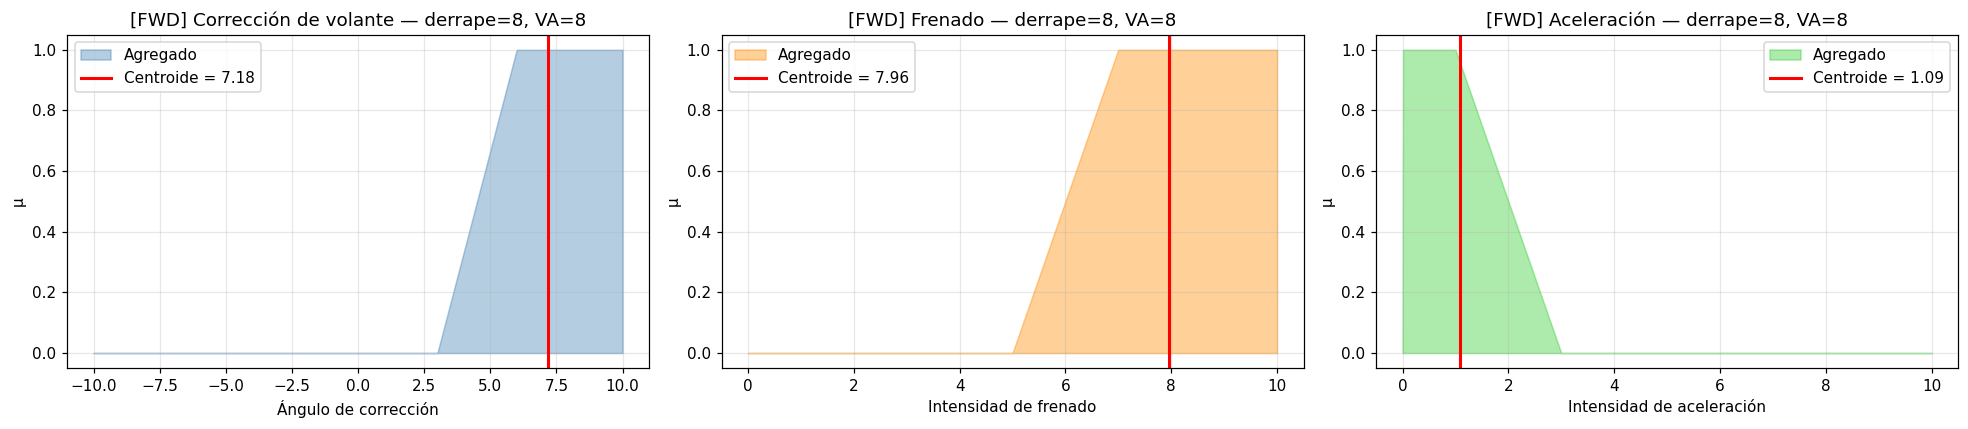


────────────────────────────────────────────────────────────
  Defuzzificación para modo RWD (derrape=8, VA=8)
  Izquierda : área agregada y centroide de corrección de volante
  Centro    : área agregada y centroide de intensidad de frenado
  Derecha   : área agregada y centroide de intensidad de aceleración
────────────────────────────────────────────────────────────


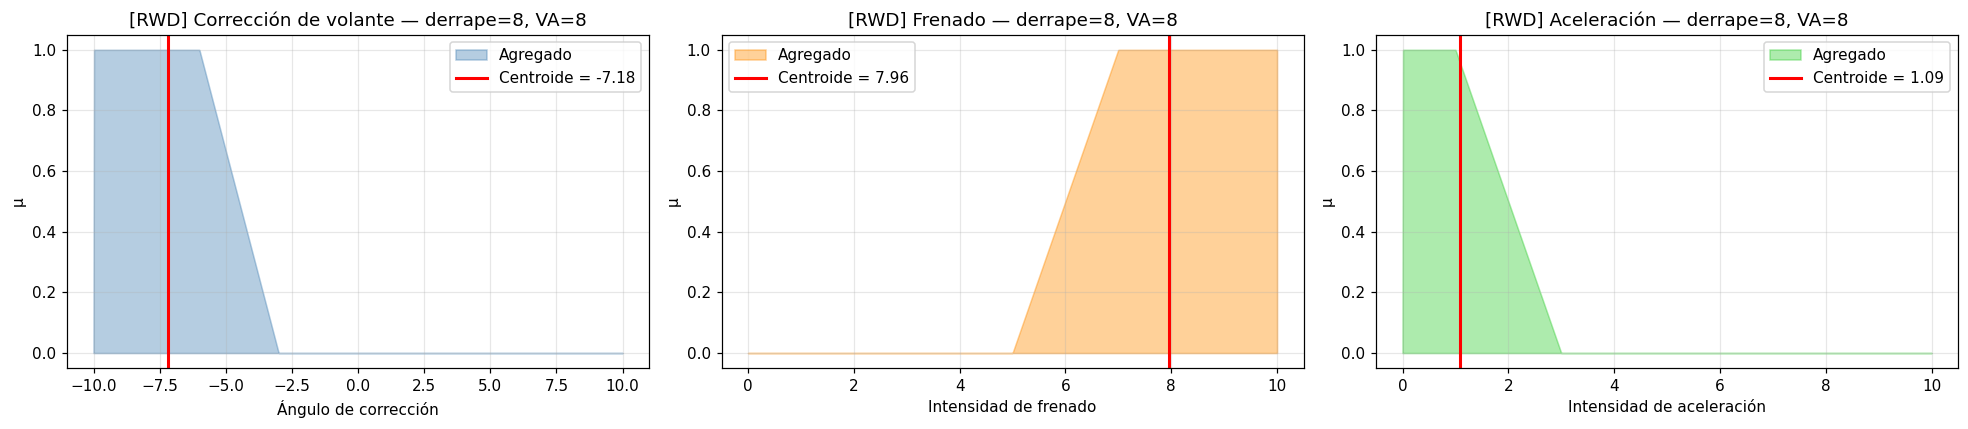

PASO 5: Visualización de la defuzzificación - Ejecutado


In [ ]:
# -----------------------------------------------------------------------------
# PASO 5: Visualización de la defuzzificación
#
# Gráfica del conjunto difuso agregado (área sombreada) y la línea vertical
# del centroide para cada consecuente.
#
# La visualización permite inspeccionar cómo la agregación de reglas da forma
# al área resultante y verificar que el centroide cae donde se espera.
# -----------------------------------------------------------------------------

def plot_defuzz(result: dict):
    """Muestra los conjuntos difusos agregados y el centroide para un resultado dado."""
    mode = result["mode"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Volante
    ax = axes[0]
    ax.fill_between(u_volante, result["_agg_volante"], alpha=0.4, color="steelblue", label="Agregado")
    ax.axvline(result["correccion_volante"], color="red", linewidth=2,
               label=f"Centroide = {result['correccion_volante']:.2f}")
    ax.set_title(f"[{mode}] Corrección de volante — derrape={result['derrape']}, VA={result['vel_ang']}")
    ax.set_xlabel("Ángulo de corrección")
    ax.set_ylabel("μ")
    ax.legend()

    # Frenado
    ax = axes[1]
    ax.fill_between(u_frenado, result["_agg_frenado"], alpha=0.4, color="darkorange", label="Agregado")
    ax.axvline(result["frenado"], color="red", linewidth=2,
               label=f"Centroide = {result['frenado']:.2f}")
    ax.set_title(f"[{mode}] Frenado — derrape={result['derrape']}, VA={result['vel_ang']}")
    ax.set_xlabel("Intensidad de frenado")
    ax.set_ylabel("μ")
    ax.legend()

    # Aceleración
    ax = axes[2]
    ax.fill_between(u_aceleracion, result["_agg_aceleracion"], alpha=0.4, color="limegreen", label="Agregado")
    ax.axvline(result["aceleracion"], color="red", linewidth=2,
               label=f"Centroide = {result['aceleracion']:.2f}")
    ax.set_title(f"[{mode}] Aceleración — derrape={result['derrape']}, VA={result['vel_ang']}")
    ax.set_xlabel("Intensidad de aceleración")
    ax.set_ylabel("μ")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Visualizar caso crítico (derrape=8, VA=8)
for mode in ["FWD", "RWD"]:
    res = infer_skid_control(8, 8, mode=mode)
    print(f"\n{'─'*60}")
    print(f"  Defuzzificación para modo {mode} (derrape=8, VA=8)")
    print(f"  Izquierda : área agregada y centroide de corrección de volante")
    print(f"  Centro    : área agregada y centroide de intensidad de frenado")
    print(f"  Derecha   : área agregada y centroide de intensidad de aceleración")
    print(f"{'─'*60}")
    plot_defuzz(res)

print("PASO 5: Visualización de la defuzzificación - Ejecutado")

# Análisis de Resultados: Simulación de Control de Derrape (FWD vs RWD)

A partir de los escenarios ejecutados, se observa que el sistema difuso no solo reacciona a la intensidad del derrape, sino que adapta la estrategia de tracción según la mecánica del vehículo.

**Diferenciación de la Estrategia de Giro (Contravolante)**:
- En derrapes leves y medios, el sistema asigna valores de volante opuestos. Para el FWD (Tracción Delantera), el volante gira hacia la derecha (+), mientras que para el RWD (Tracción Trasera), gira hacia la izquierda (-).

**Gestión de Potencia y Frenado**:
- Escenario Leve: En el FWD se observa una aceleración alta (4.00) frente a una baja en el RWD (1.09). Esto es correcto: en tracción delantera, acelerar suavemente ayuda a "tirar" del coche hacia la trayectoria deseada, mientras que en tracción trasera, acelerar en pleno derrape empeoraría el giro sobre el propio eje.

- Escenarios Críticos: Cuando el derrape y la velocidad angular son altos (8), el sistema prioriza la seguridad sobre la tracción, igualando el frenado en ambos sistemas (7.96) para reducir la energía cinética del vehículo.

**Neutralidad**
- Escenario Derrape Fuerte / Baja Vel. Angular: Es muy interesante que con un derrape de 8 pero velocidad angular de 2, el volante marque 0.00 (Neutro).

# Superficie de control

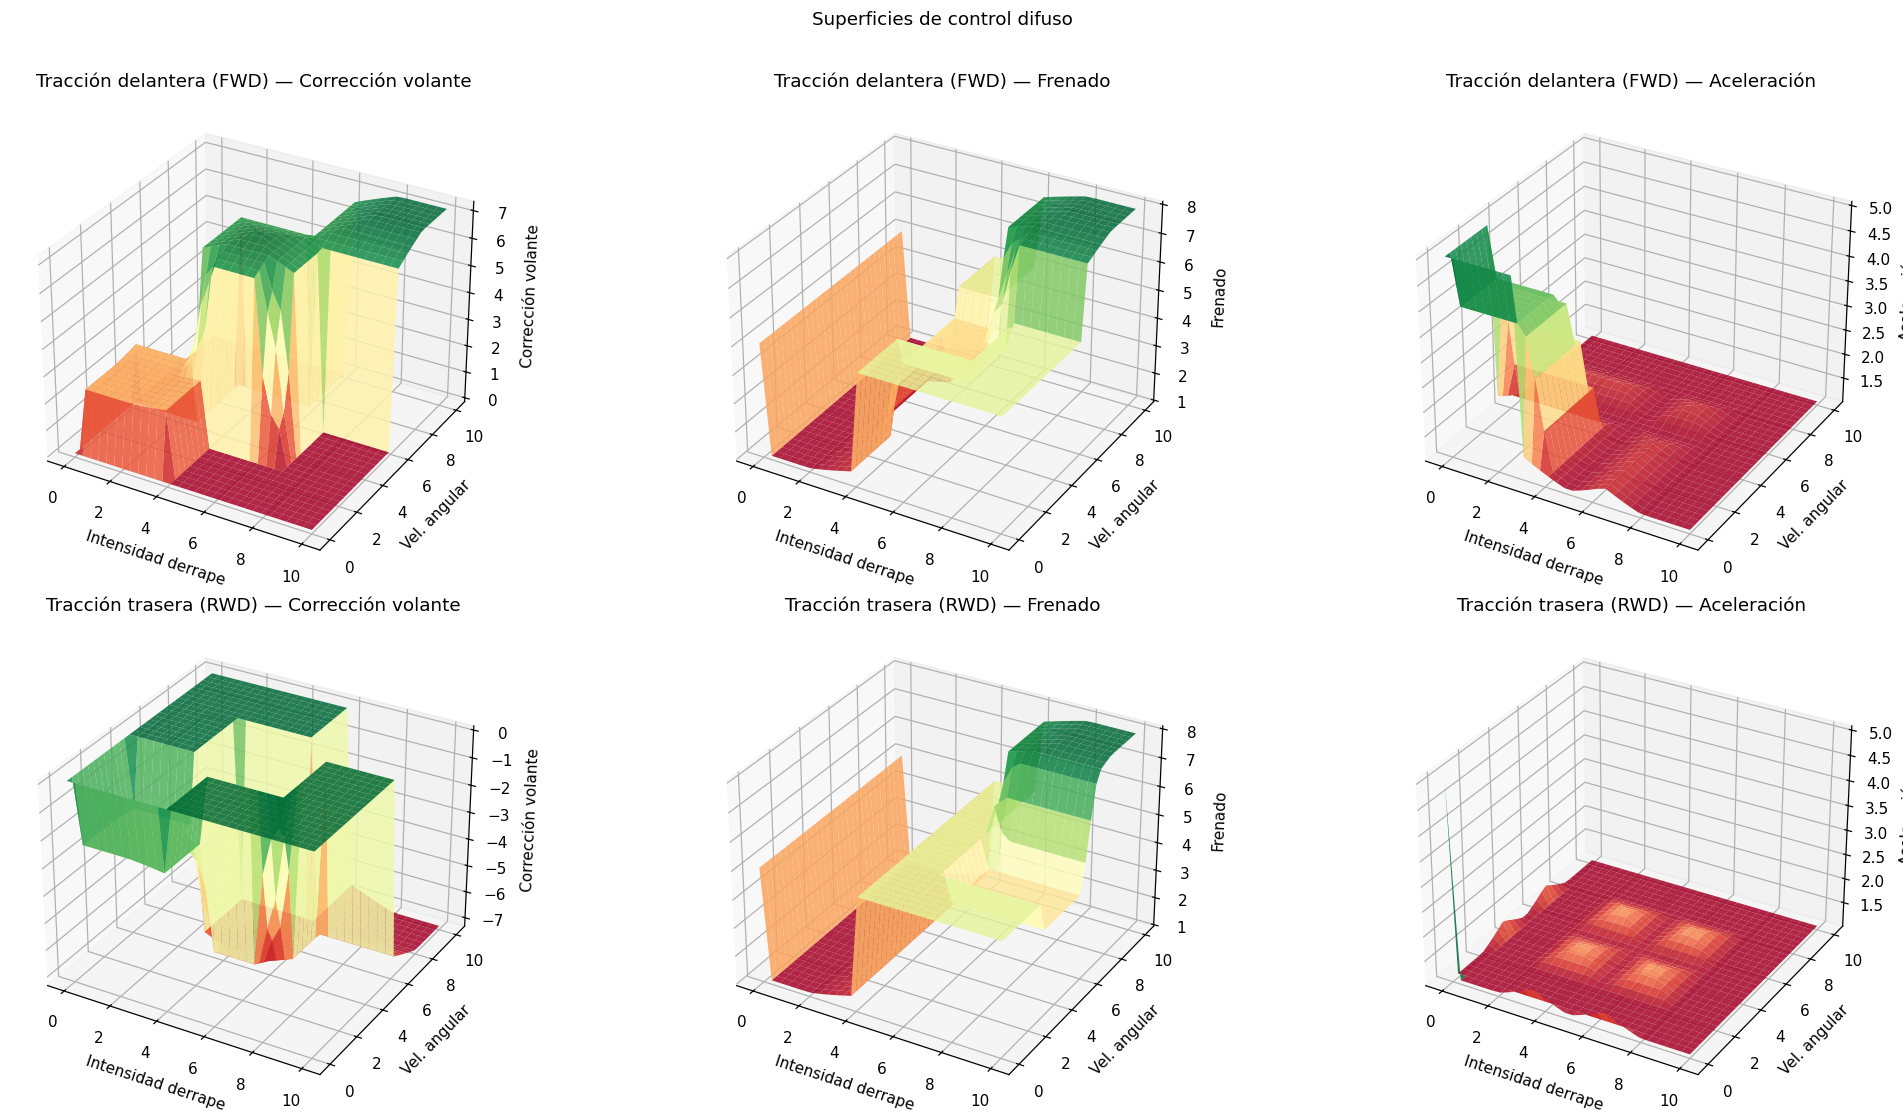

PASO 6: Superficie de control - Ejecutado


In [ ]:
# -----------------------------------------------------------------------------
# PASO 6: Superficie de control
#
# Se genera un mapa 3D que muestra cómo varía la corrección de volante
# para cada combinación posible de (intensidad_derrape, velocidad_angular).
#
# La superficie de control es útil porque:
#   - Muestra cómo varía la corrección de volante en función de ambas entradas.
#   - Permite detectar discontinuidades o comportamientos inesperados del sistema.
#   - Es una herramienta estándar de validación en diseño de sistemas difusos.
#   - Facilita comparar visualmente la diferencia de estrategia FWD vs RWD.
# -----------------------------------------------------------------------------

d_range = np.linspace(0, 10, 30)
v_range = np.linspace(0, 10, 30)
D, V = np.meshgrid(d_range, v_range)

Z_volante_fwd = np.zeros_like(D)
Z_volante_rwd = np.zeros_like(D)
Z_frenado_fwd = np.zeros_like(D)
Z_frenado_rwd = np.zeros_like(D)
Z_aceleracion_fwd = np.zeros_like(D)
Z_aceleracion_rwd = np.zeros_like(D)

for i in range(D.shape[0]):
    for j in range(D.shape[1]):
        res_fwd = infer_skid_control(D[i, j], V[i, j], "FWD")
        Z_volante_fwd[i, j] = res_fwd["correccion_volante"]
        Z_frenado_fwd[i, j] = res_fwd["frenado"]
        Z_aceleracion_fwd[i, j] = res_fwd["aceleracion"]

        res_rwd = infer_skid_control(D[i, j], V[i, j], "RWD")
        Z_volante_rwd[i, j] = res_rwd["correccion_volante"]
        Z_frenado_rwd[i, j] = res_rwd["frenado"]
        Z_aceleracion_rwd[i, j] = res_rwd["aceleracion"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10), subplot_kw={"projection": "3d"})

plot_data = [
    # Fila superior: todas las acciones para FWD
    (Z_volante_fwd, "Tracción delantera (FWD) — Corrección volante", axes[0, 0]),
    (Z_frenado_fwd, "Tracción delantera (FWD) — Frenado", axes[0, 1]),
    (Z_aceleracion_fwd, "Tracción delantera (FWD) — Aceleración", axes[0, 2]),
    # Fila inferior: todas las acciones para RWD
    (Z_volante_rwd, "Tracción trasera (RWD) — Corrección volante", axes[1, 0]),
    (Z_frenado_rwd, "Tracción trasera (RWD) — Frenado", axes[1, 1]),
    (Z_aceleracion_rwd, "Tracción trasera (RWD) — Aceleración", axes[1, 2]),
]

for Z, title, ax in plot_data:
    ax.plot_surface(D, V, Z, cmap="RdYlGn", alpha=0.85)
    ax.set_xlabel("Intensidad derrape")
    ax.set_ylabel("Vel. angular")
    ax.set_zlabel(title.split('—')[-1].strip())
    ax.set_title(title)

plt.suptitle("Superficies de control difuso", y=1.01)
plt.tight_layout()
plt.show()

print("PASO 6: Superficie de control - Ejecutado")

# Interpretación general de las superficies de control

Estos gráficos nos permiten apreciar varias características clave del sistema:

No linealidad controlada: La respuesta del sistema no es lineal, lo que es una ventaja de la lógica difusa. Las transiciones de una respuesta mínima a una máxima son suaves y graduadas.

- **Saturación**: Las mesetas indican que el sistema tiene un límite superior en su capacidad de respuesta, lo cual es realista en un control físico.

- **Manejo de casos especiales:** La caída a 0 en la corrección del volante para derrapes altos con baja velocidad angular demuestra que el sistema es capaz de implementar reglas de excepción para situaciones específicas, evitando acciones contraproducentes.

- **Diferenciación de estrategias:** Se puede observar claramente cómo las estrategias de volante y aceleración difieren entre FWD y RWD, mientras que la estrategia de frenado converge en situaciones de alta severidad.

# Fila superior: Tracción delantera (FWD)

- **Corrección de volante (FWD):**
Muestra que, para la tracción delantera, el sistema aplica una corrección de volante en la misma dirección del derrape. La intensidad de esta corrección es nula o muy baja para derrapes leves, aumenta significativamente para derrapes medios y fuertes (hasta un máximo), y se anula si el derrape es fuerte pero no hay rotación del chasis (indicando un derrape en línea recta).

- **Frenado (FWD):**
Indica que el sistema de tracción delantera opta por frenar de manera progresiva. El frenado es mínimo para derrapes leves y aumenta de forma gradual, volviéndose muy fuerte a medida que la intensidad del derrape y la velocidad angular se hacen críticas.

- **Aceleración (FWD):**
Para FWD, la estrategia es reducir la aceleración en casi todas las condiciones de derrape. Solo se permite una aceleración muy suave en escenarios de derrape extremadamente leve y baja velocidad angular, pero rápidamente se suprime al aumentar la severidad del derrape.

# Fila inferior: Tracción trasera (RWD)

- **Corrección de volante (RWD):**
Esta superficie es un espejo de la FWD, lo que significa que el sistema para tracción trasera aplica una corrección de volante en la dirección opuesta al derrape (contra-dirección). La lógica de activación es la misma que en FWD (nula para derrapes leves, fuerte para derrapes medios/altos), pero con el sentido invertido. También anula la corrección en caso de derrape fuerte sin rotación del chasis.

- **Frenado (RWD):**
El comportamiento de frenado es muy similar al FWD, siendo mínimo en derrapes leves y aumentando drásticamente en situaciones críticas. La principal diferencia, aunque sutil, es que este modo evita un frenado agresivo en derrapes medios para no exacerbar el sobreviraje.

- **Aceleración (RWD):**
La superficie de aceleración para RWD es casi plana y cercana a cero. Esto sugiere que la estrategia dominante es cortar la aceleración casi por completo tan pronto como se detecta un derrape. Esto se alinea con la recomendación de una 'liberación de gas más agresiva' en RWD para manejar el sobreviraje y evitar perder más tracción en las ruedas motrices.

<div style="
    background: linear-gradient(90deg, #1a73e8 0%, #ffffff 100%);
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h2 style="color: white; margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    🚀 SECCIÓN 2 - Experimentación con lógica difusa: Aplicación en entorno de trabajo
  </h2>
</div>

# Sistema difuso para evaluación de proyectos de desarrollo

## Descripción del problema
En el contexto de la evaluación ex-post de proyectos de desarrollo,
determinar el nivel de eficiencia y efectividad de ejecución de un
proyecto no es una decisión binaria. Un proyecto puede haber cumplido
sus metas financieras pero haber tenido bajo impacto social, o haber
ejecutado bien institucionalmente pero con riesgos ambientales no
gestionados. La lógica difusa permite capturar esta naturaleza
multidimensional y gradual de la evaluación.

## Objetivo del sistema
Diseñar un sistema de inferencia difusa tipo Mamdani que, a partir de
cinco variables de entrada que caracterizan la ejecución de un proyecto,
produzca un puntaje de eficiencia y efectividad en escala [0, 10],
donde 0 representa ejecución deficiente y 10 representa ejecución sobresaliente.

## Variables del sistema

### Antecedentes (entradas)

| Variable                  | Descripción                                                        | Rango   | Variables Lingüísticas                 |
|:--------------------------|:-------------------------------------------------------------------|:--------|:---------------------------------------|
| `impacto_social`          | Grado en que el proyecto benefició a la población objetivo         | `[0, 10]` | Bajo, Medio, Alto                      |
| `viabilidad_financiera`   | Nivel de eficiencia en el uso de los recursos asignados            | `[0, 10]` | Baja, Media, Alta                      |
| `capacidad_institucional` | Fortaleza del ejecutor para gestionar y sostener el proyecto       | `[0, 10]` | Baja, Media, Alta                      |
| `riesgo_ambiental`        | Nivel de impacto ambiental negativo generado (0=ninguno, 10=alto)  | `[0, 10]` | Bajo, Medio, Alto                      |
| `cumplimiento_metas`      | Porcentaje de objetivos e indicadores alcanzados al cierre         | `[0, 10]` | Bajo, Medio, Alto                      |


### Consecuente (salida)

| Variable                 | Descripción                                                        | Rango   | Variables Lingüísticas                               |
|:-------------------------|:-------------------------------------------------------------------|:--------|:-----------------------------------------------------|
| `eficiencia_efectividad` | Puntaje global de eficiencia y efectividad de ejecución            | `[0, 10]` | Deficiente, Regular, Aceptable, Bueno, Sobresaliente |


## Pipeline de resolución propuesto

Para resolver este sistema se seguirían las mismas 4 etapas del pipeline
Mamdani aplicado en la Sección 1:

**1. Fuzzificación**
Cada valor nítido de entrada (p.ej. impacto_social = 6.5) se evalúa en
sus funciones de membresía para obtener los grados μ correspondientes.
Se usarán funciones trapezoidales en los extremos y triangulares en los
valores intermedios, igual que en la Sección 1.a.

**2. Evaluación de reglas**
Se definen reglas IF–THEN que combinan las cinco variables de entrada.
Por ejemplo:
- IF `impacto_social` es Alto AND `viabilidad_financiera` es Alta AND `capacidad_institucional` es Alta AND `riesgo_ambiental` es Bajo AND `cumplimiento_metas` es Alto THEN `eficiencia_efectividad` es Sobresaliente.
- IF `viabilidad_financiera` es Baja OR `capacidad_institucional` es Baja OR `riesgo_ambiental` es Alto THEN `eficiencia_efectividad` es Deficiente.
- IF `impacto_social` es Medio AND `viabilidad_financiera` es Media AND `cumplimiento_metas` es Medio THEN `eficiencia_efectividad` es Aceptable.
El operador AND se implementa como mínimo (t-norma), el OR como máximo (s-norma).

**3. Agregación**
Las salidas de todas las reglas activas se combinan con np.fmin
(implicación de Mamdani) y np.fmax (unión difusa), produciendo un
único conjunto difuso de salida.

**4. Defuzzificación**
Se aplica el método del centroide sobre el conjunto agregado para
obtener el puntaje nítido final de eficiencia y efectividad.

In [ ]:
# -----------------------------------------------------------------------------
# PASO 1: Definir universos de discurso
#
# Todas las variables se normalizan en la escala [0, 10] para homogeneidad.
# Se usan 1000 puntos por universo para garantizar precisión en el centroide.
#
# Excepción: riesgo_ambiental tiene semántica inversa (mayor valor = peor
# desempeño). Esto NO se corrige en el universo sino en las reglas difusas,
# donde un riesgo "Alto" activa consecuentes de baja eficiencia.
# -----------------------------------------------------------------------------

u_impacto_social        = np.linspace(0, 10, 1000)  # Beneficio a población objetivo
u_viabilidad_financiera = np.linspace(0, 10, 1000)  # Eficiencia en uso de recursos
u_capacidad_inst        = np.linspace(0, 10, 1000)  # Fortaleza institucional del ejecutor
u_riesgo_ambiental      = np.linspace(0, 10, 1000)  # Impacto ambiental negativo (inverso)
u_cumplimiento_metas    = np.linspace(0, 10, 1000)  # Objetivos e indicadores alcanzados
u_eficiencia            = np.linspace(0, 10, 1000)  # Salida: puntaje de eficiencia global

print("""
Universos de discurso definidos — Sección 1.b

  Antecedentes (entradas):
    · impacto_social        : [0, 10] — 0=sin impacto,       10=impacto máximo
    · viabilidad_financiera : [0, 10] — 0=uso ineficiente,   10=uso óptimo
    · capacidad_inst        : [0, 10] — 0=ejecutor débil,    10=ejecutor sólido
    · riesgo_ambiental      : [0, 10] — 0=sin riesgo,        10=riesgo crítico (semántica inversa)
    · cumplimiento_metas    : [0, 10] — 0=ninguna meta lograda, 10=todas las metas logradas

  Consecuente (salida):
    · eficiencia            : [0, 10] — 0=deficiente, 10=sobresaliente

  Siguiente paso: definir las funciones de membresía para cada universo
  y construir la base de reglas IF-THEN que relacione las entradas con
  el puntaje de eficiencia y efectividad.
""")

print("SECCIÓN 1.b — PASO 1: Universos de discurso definidos.")


Universos de discurso definidos — Sección 1.b

  Antecedentes (entradas):
    · impacto_social        : [0, 10] — 0=sin impacto,       10=impacto máximo
    · viabilidad_financiera : [0, 10] — 0=uso ineficiente,   10=uso óptimo
    · capacidad_inst        : [0, 10] — 0=ejecutor débil,    10=ejecutor sólido
    · riesgo_ambiental      : [0, 10] — 0=sin riesgo,        10=riesgo crítico (semántica inversa)
    · cumplimiento_metas    : [0, 10] — 0=ninguna meta lograda, 10=todas las metas logradas

  Consecuente (salida):
    · eficiencia            : [0, 10] — 0=deficiente, 10=sobresaliente

  Siguiente paso: definir las funciones de membresía para cada universo
  y construir la base de reglas IF-THEN que relacione las entradas con
  el puntaje de eficiencia y efectividad.

SECCIÓN 1.b — PASO 1: Universos de discurso definidos.


## Conclusiones: Logica Difusa — Control de Derrape Vehicular y caso práctico

### Caso A (FWD) vs Caso B (RWD)

- El sistema aplica contravolante automático en RWD (Valores negativos) para corregir el sobreviraje, mientras que en FWD usa correcciones positivas para mitigar el subviraje.
- En derrapes leves ($2,2$), el modelo FWD acelera proactivamente (4.00) para "tirar" del vehículo, mientras el RWD se mantiene conservador (1.09) para evitar la pérdida de adherencia trasera.
- Ante derrapes fuertes ($8,8$), el sistema jerarquiza la estabilidad sobre la trayectoria, igualando el frenado máximo (7.96) en ambas tracciones para reducir la energía cinética.
- En el escenario de derrape fuerte con baja rotación ($8,2$), el controlador detecta la ineficacia del giro y activa un estado Neutro (0.00) con frenado intermedio, priorizando recuperar el agarre lineal antes de maniobrar.

### Sistema evaluación de proyectos de desarrollo

- Al integrar variables con semánticas opuestas como el impacto social (proactivo) y el riesgo ambiental (limitador), el sistema garantiza una visión holística de la eficiencia. Esta estructura prepara el terreno para que las funciones de membresía traduzcan datos nítidos en conceptos lingüísticos, permitiendo que el motor de inferencia Mamdani capture la complejidad del éxito institucional más allá de un simple cumplimiento financiero.

<div style="
    background: linear-gradient(90deg, #1a73e8 0%, #ffffff 100%);
    padding: 10px 20px;
    border-radius: 5px 5px 0 0;
    border-bottom: 3px solid #174ea6;
    margin-bottom: 15px;">
  <h2 style="color: white; margin: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    🚀 SECCIÓN 3: Algoritmo PSO — Formacion de Drones
  </h2>
</div>

## Problema

Implementar un algoritmo de navegación colectiva capaz de posicionar una flota de drones en configuraciones geométricas específicas (línea, triangulo, rectangulo, H, cīrculo) mediante la técnica metaheurística **Optimizacion por Enjambre de Particulas (PSO)**. La arquitectura del sistema prioriza el **Error de formacion**, **Colisiones** y los **Limites del area** del enjambre a través de una función de aptitud diseñada para penalizar  utilizando .

Para es necesario tener claros los siguientes coneptos de la **funcion de fitness** y lo que penaliza:
- **Error de formación** — Qué tan bien están los drones la figura (como la "H", el rectangulo o círculo) sin que las piezas queden en desorden.

- **Colisiones** — El cuidado de que los drones no se choquen entre sí y mantengan siempre su "espacio personal" de seguridad.

- **Límites del área** — El control para que ningún dron se escape del área definida o de la zona donde les toca volar.




>>> Procesando Optimización Bioinspirada: Linea


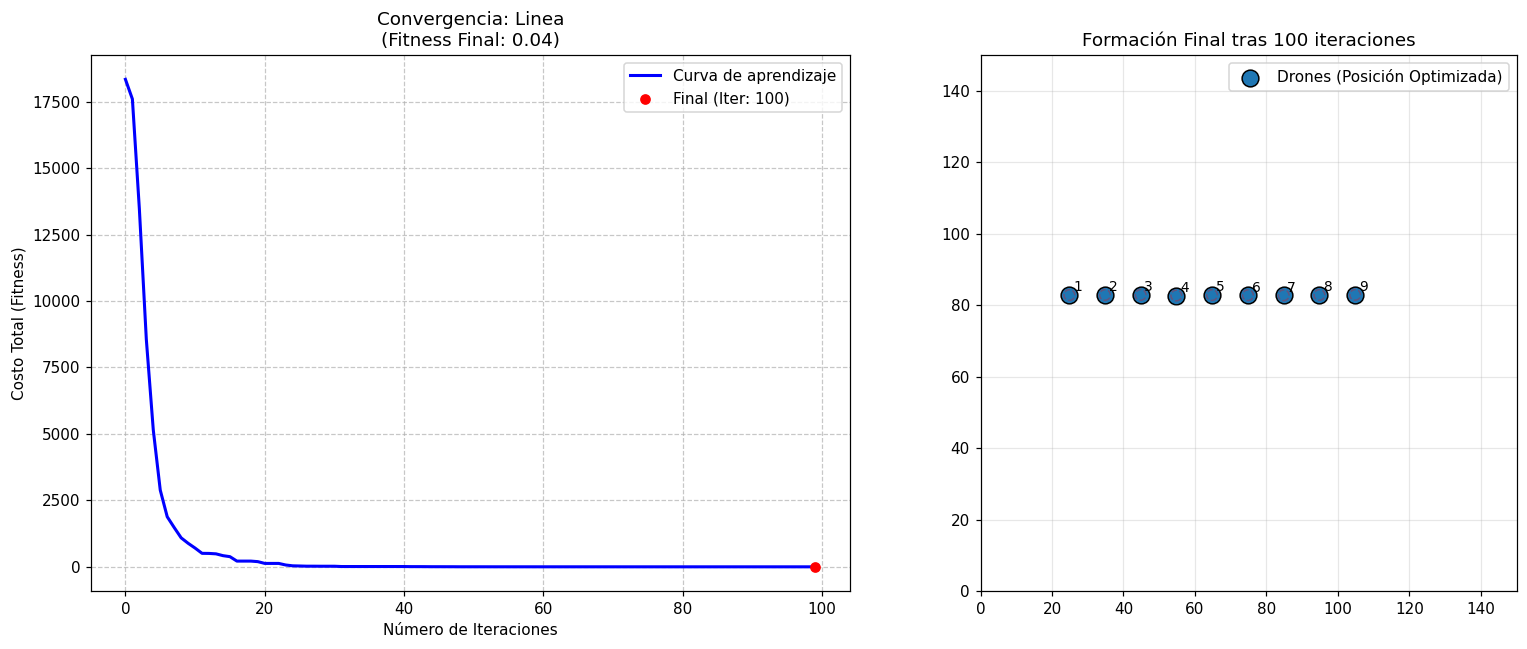


>>> Procesando Optimización Bioinspirada: Triangulo


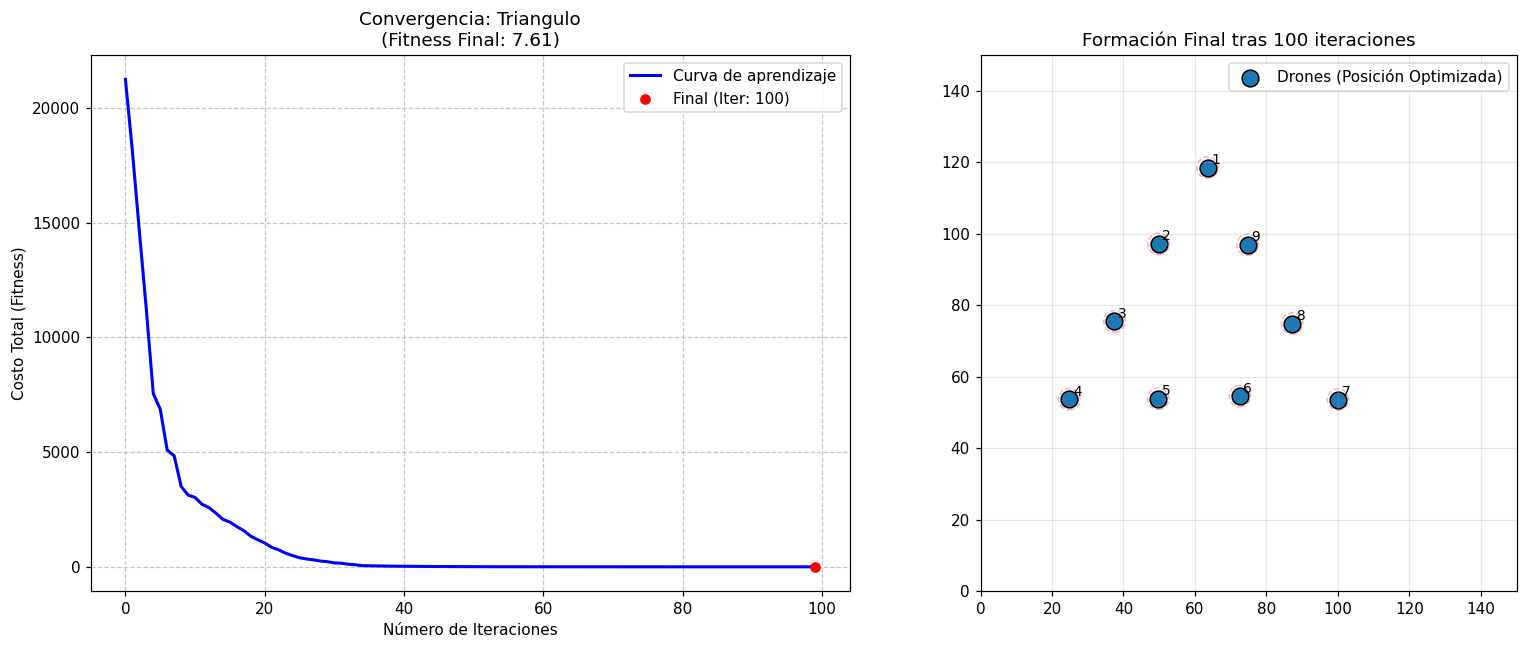


>>> Procesando Optimización Bioinspirada: Rectangulo


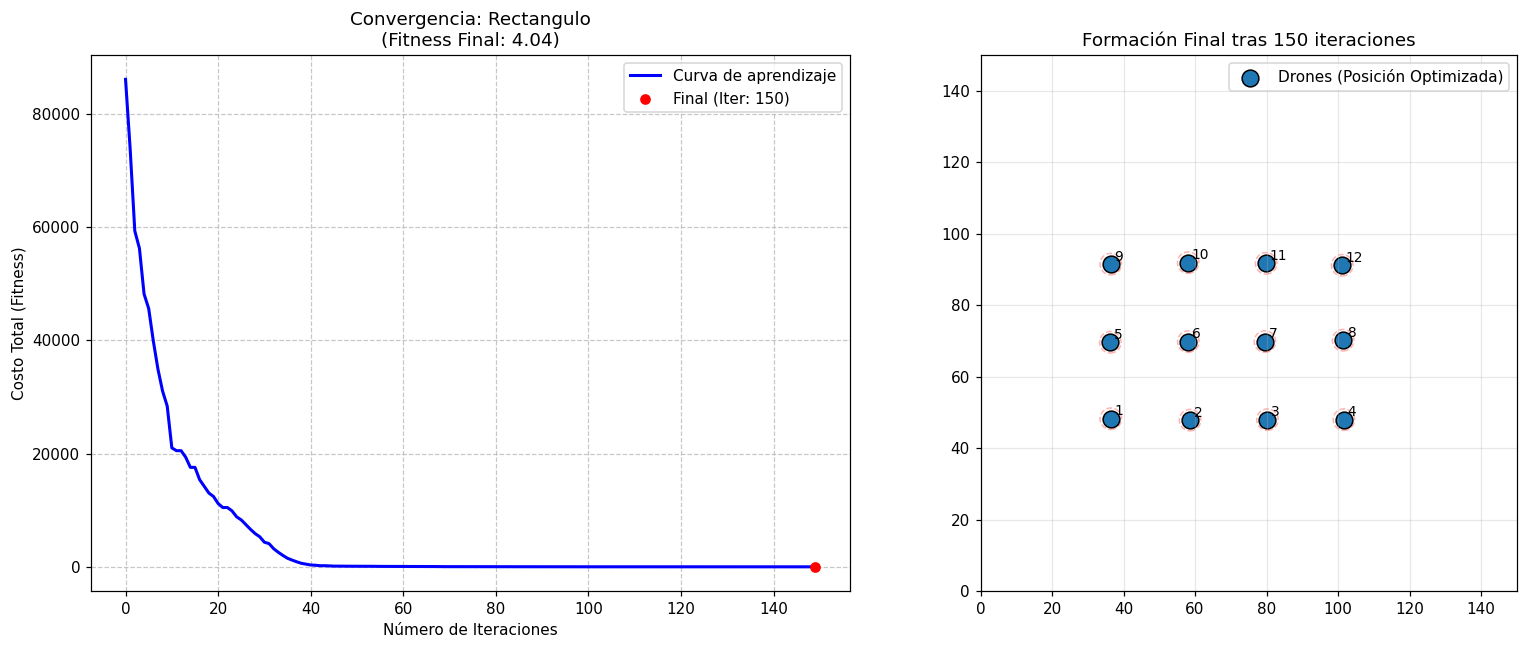


>>> Procesando Optimización Bioinspirada: H


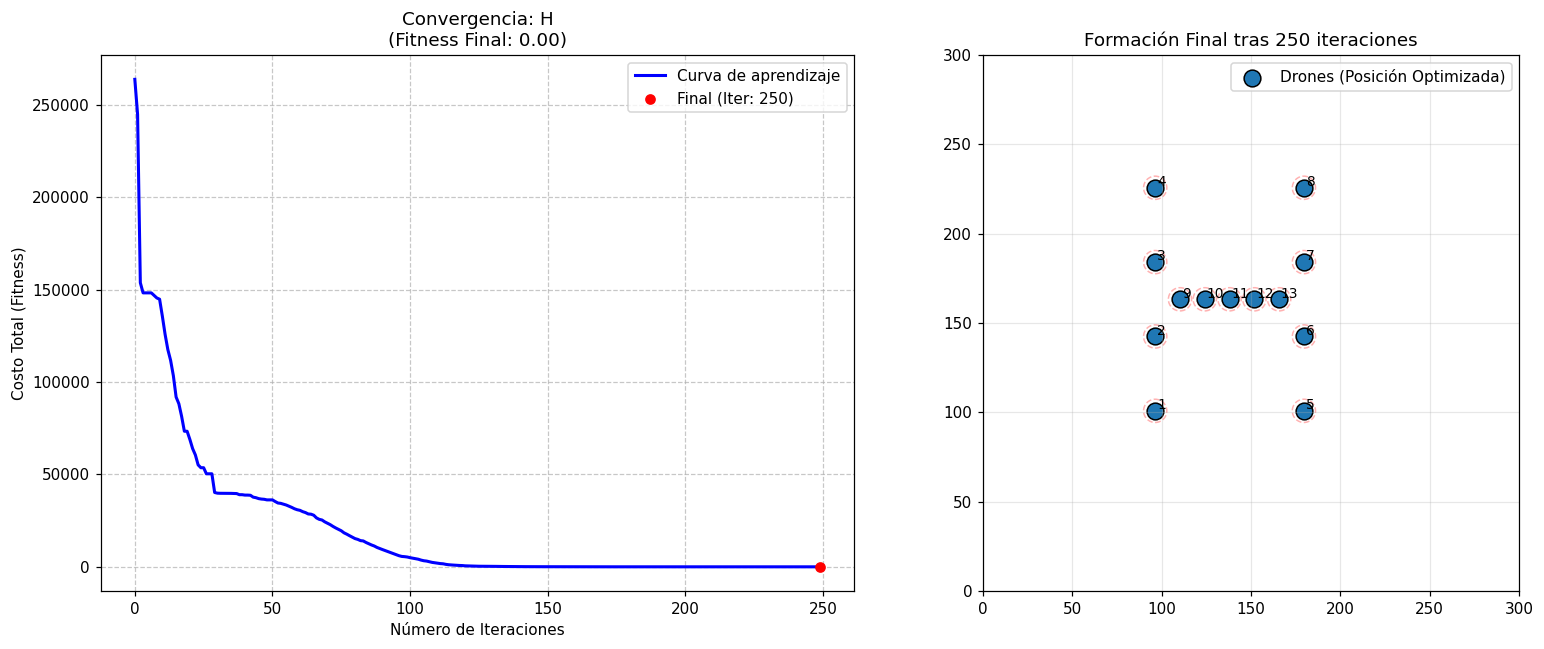


>>> Procesando Optimización Bioinspirada: Circulo


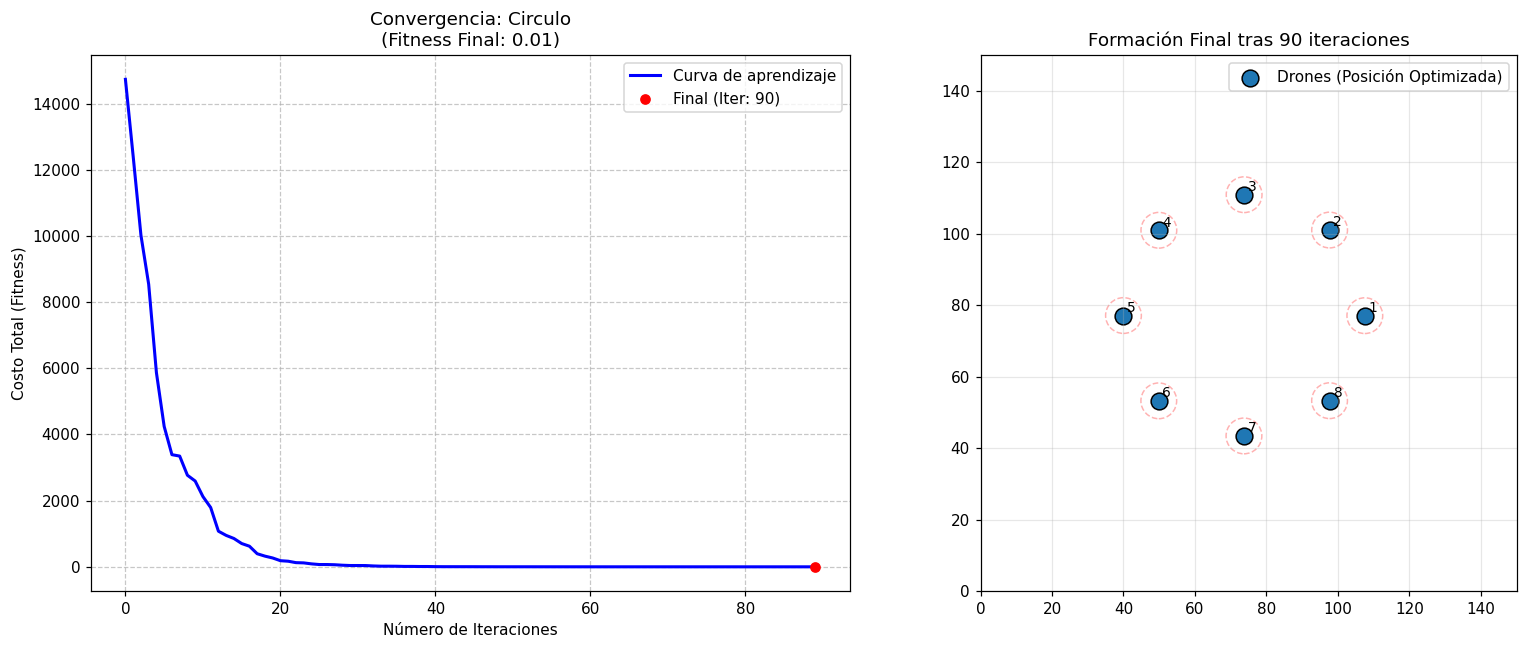

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Fijamos semillas para reproducibilidad
np.random.seed(42)
random.seed(42)

# *****************************************************************************
# PARÁMETROS PARA CADA UNA DE LAS FORMACIONES
# *****************************************************************************
# NUM_DRONES = Numero de drones en la flota dependiendo de la formación
# DIMENSIONS = Espacio bidimensional (X, Y)
# AREA_WIDTH = Ancho del area de vuelo
# AREA_HEIGHT = Alto del area de vuelo
# MIN_SAFE_DISTANCE = Distancia minima de seguridad entre drones
# FORMATION_DISTANCE_L = Distancia de separacion deseada en la formación
# *****************************************************************************


# *****************************************************************************
# PARÁMETROS DEL ALGORITMO PSO
# *****************************************************************************
# NUM_PARTICLES = Numero de particulas del enjambre
# MAX_ITERATIONS = Iteraciones máximas del algoritmo
# W = Inercia: Controla la exploración vs explotación. Un valor medio evita oscilaciones.
# C1 = Coeficiente Cognitivo: Peso del aprendizaje individual (pBest).
# C2 = Coeficiente Social: Peso del aprendizaje colectivo (gBest).
# V_MAX = Velocidad Máxima: Límite físico para evitar que las partículas "salten" fuera del óptimo.
# *****************************************************************************

def ejecutar_pso_formacion(tipo_formacion):
    """
    Función que encapsula el ciclo de vida del algoritmo PSO para una geometría específica.
    Permite el análisis comparativo de hiperparámetros y su impacto en la convergencia.
    """
    print(f"\n>>> Procesando Optimización Bioinspirada: {tipo_formacion}")

    # ----- 1. CONFIGURACIÓN DE PARÁMETROS SEGÚN FORMACIÓN ----- #
    if tipo_formacion == "Linea":

        # --- CONFIGURACIÓN DE ESPACIO Y FLOTA ---
        NUM_DRONES = 9               # Número de agentes para una formación simétrica (múltiplo de 3)
        AREA_WIDTH = 150             # Límite horizontal del espacio de misión
        AREA_HEIGHT = 150            # Límite vertical del espacio de misión
        MIN_SAFE_DISTANCE = 3        # Radio de seguridad mínimo para evitar colisiones físicas

        # --- AJUSTE DINÁMICO DE ESCALA ---
        # La distancia de seguridad ni exceder el área de trabajo.
        FORMATION_DISTANCE_L = 10

        # --- HIPERPARÁMETROS DEL ENJAMBRE (PSO) ---
        NUM_PARTICLES = 40           # Cantidad de soluciones candidatas explorando el espacio
        MAX_ITERATIONS = 100         # Límite de generaciones para alcanzar la convergencia estable

        # --- DINÁMICA DE MOVIMIENTO ---
        W = 0.7                      # Inercia: Equilibra la exploración global con la explotación local
        C1 = 1.2                    # Coeficiente Cognitivo: Influencia de la mejor posición personal (pBest)
        C2 = 1.8                     # Coeficiente Social: Influencia del líder del enjambre (gBest)
        V_MAX = 12.0                 # Límite de velocidad para prevenir divergencia y saltos erráticos

        # --- PONDERACIÓN DE LA FUNCIÓN FITNESS ---
        # Estos pesos definen la prioridad del algoritmo al evaluar el desempeño.
        w1 = 1.0                     # Peso de Precisión: Fidelidad a los vértices del triángulo
        w2 = 20.0                    # Peso de Seguridad: Prioridad crítica para evitar colisiones
        w3 = 15.0                    # Peso de Confinamiento: Penalización por salida del área

    elif tipo_formacion == "Triangulo":

        # --- CONFIGURACIÓN DE ESPACIO Y FLOTA ---
        NUM_DRONES = 9               # Número de agentes para una formación simétrica (múltiplo de 3)
        AREA_WIDTH = 150             # Límite horizontal del espacio de misión
        AREA_HEIGHT = 150            # Límite vertical del espacio de misión
        MIN_SAFE_DISTANCE = 6        # Radio de seguridad mínimo para evitar colisiones físicas

        # --- AJUSTE DINÁMICO DE ESCALA ---
        # Garantiza que la formación mantenga su proporción geométrica sin violar
        # la distancia de seguridad ni exceder el área de trabajo.
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))

        # --- HIPERPARÁMETROS DEL ENJAMBRE (PSO) ---
        NUM_PARTICLES = 40           # Cantidad de soluciones candidatas explorando el espacio
        MAX_ITERATIONS = 100         # Límite de generaciones para alcanzar la convergencia estable

        # --- DINÁMICA DE MOVIMIENTO ---
        W = 0.5                      # Inercia: Equilibra la exploración global con la explotación local
        C1 = 1.5                     # Coeficiente Cognitivo: Influencia de la mejor posición personal (pBest)
        C2 = 1.5                     # Coeficiente Social: Influencia del líder del enjambre (gBest)
        V_MAX = 10.0                 # Límite de velocidad para prevenir divergencia y saltos erráticos

        # --- PONDERACIÓN DE LA FUNCIÓN FITNESS ---
        # Estos pesos definen la prioridad del algoritmo al evaluar el desempeño.
        w1 = 1.0                     # Peso de Precisión: Fidelidad a los vértices del triángulo
        w2 = 40.0                    # Peso de Seguridad: Prioridad crítica para evitar colisiones
        w3 = 10.0                    # Peso de Confinamiento: Penalización por salida del área

    elif tipo_formacion == "Rectangulo":

        # --- CONFIGURACIÓN DE ESPACIO Y FLOTA ---
        NUM_DRONES = 12               # Número de agentes para una formación simétrica (múltiplo de 3)
        AREA_WIDTH = 150             # Límite horizontal del espacio de misión
        AREA_HEIGHT = 150            # Límite vertical del espacio de misión
        MIN_SAFE_DISTANCE = 6        # Radio de seguridad mínimo para evitar colisiones físicas

        # --- AJUSTE DINÁMICO DE ESCALA ---
        # Garantiza que la formación mantenga su proporción geométrica sin violar
        # la distancia de seguridad ni exceder el área de trabajo.
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))

        # --- HIPERPARÁMETROS DEL ENJAMBRE (PSO) ---
        NUM_PARTICLES = 100           # Cantidad de soluciones candidatas explorando el espacio
        MAX_ITERATIONS = 150         # Límite de generaciones para alcanzar la convergencia estable

        # --- DINÁMICA DE MOVIMIENTO ---
        W = 0.4                      # Inercia: Equilibra la exploración global con la explotación local
        C1 = 1.2                     # Coeficiente Cognitivo: Influencia de la mejor posición personal (pBest)
        C2 = 3.0                     # Coeficiente Social: Influencia del líder del enjambre (gBest)
        V_MAX = 5.0                 # Límite de velocidad para prevenir divergencia y saltos erráticos

        # --- PONDERACIÓN DE LA FUNCIÓN FITNESS ---
        # Estos pesos definen la prioridad del algoritmo al evaluar el desempeño.
        w1 = 3.0                     # Peso de Precisión: Fidelidad a los vértices del triángulo
        w2 = 60.0                    # Peso de Seguridad: Prioridad crítica para evitar colisiones
        w3 = 10.0                    # Peso de Confinamiento: Penalización por salida del área

    elif tipo_formacion == "H":

        # --- CONFIGURACIÓN DE ESPACIO Y FLOTA ---
        NUM_DRONES = 13               # Número de agentes para una formación simétrica (múltiplo de 3)
        AREA_WIDTH = 300             # Límite horizontal del espacio de misión
        AREA_HEIGHT = 300            # Límite vertical del espacio de misión
        MIN_SAFE_DISTANCE = 13        # Radio de seguridad mínimo para evitar colisiones físicas

        # --- AJUSTE DINÁMICO DE ESCALA ---
        # Garantiza que la formación mantenga su proporción geométrica sin violar
        # la distancia de seguridad ni exceder el área de trabajo.
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))

        # --- HIPERPARÁMETROS DEL ENJAMBRE (PSO) ---
        NUM_PARTICLES = 120           # Cantidad de soluciones candidatas explorando el espacio
        MAX_ITERATIONS = 250         # Límite de generaciones para alcanzar la convergencia estable

        # --- DINÁMICA DE MOVIMIENTO ---
        W = 0.5                      # Inercia: Equilibra la exploración global con la explotación local
        C1 = 1.8                    # Coeficiente Cognitivo: Influencia de la mejor posición personal (pBest)
        C2 = 1.8                     # Coeficiente Social: Influencia del líder del enjambre (gBest)
        V_MAX = 5.0                 # Límite de velocidad para prevenir divergencia y saltos erráticos

        # --- PONDERACIÓN DE LA FUNCIÓN FITNESS ---
        # Estos pesos definen la prioridad del algoritmo al evaluar el desempeño.
        w1 = 2.0                     # Peso de Precisión: Fidelidad a los vértices del triángulo
        w2 = 50.0                    # Peso de Seguridad: Prioridad crítica para evitar colisiones
        w3 = 10.0                    # Peso de Confinamiento: Penalización por salida del área

    elif tipo_formacion == "Circulo":

        # --- CONFIGURACIÓN DE ESPACIO Y FLOTA ---
        NUM_DRONES = 8               # Número de agentes para una formación simétrica (múltiplo de 3)
        AREA_WIDTH = 150             # Límite horizontal del espacio de misión
        AREA_HEIGHT = 150            # Límite vertical del espacio de misión
        MIN_SAFE_DISTANCE = 10        # Radio de seguridad mínimo para evitar colisiones físicas

        # --- AJUSTE DINÁMICO DE ESCALA ---
        # Garantiza que la formación mantenga su proporción geométrica sin violar
        # la distancia de seguridad ni exceder el área de trabajo.
        FORMATION_DISTANCE_L = max(MIN_SAFE_DISTANCE * 1.2, AREA_WIDTH / (np.sqrt(NUM_DRONES) * 2))

        # --- HIPERPARÁMETROS DEL ENJAMBRE (PSO) ---
        NUM_PARTICLES = 40           # Cantidad de soluciones candidatas explorando el espacio
        MAX_ITERATIONS = 90         # Límite de generaciones para alcanzar la convergencia estable

        # --- DINÁMICA DE MOVIMIENTO ---
        W = 0.6                      # Inercia: Equilibra la exploración global con la explotación local
        C1 = 1.4                     # Coeficiente Cognitivo: Influencia de la mejor posición personal (pBest)
        C2 = 1.6                     # Coeficiente Social: Influencia del líder del enjambre (gBest)
        V_MAX = 10.0                 # Límite de velocidad para prevenir divergencia y saltos erráticos

        # --- PONDERACIÓN DE LA FUNCIÓN FITNESS ---
        # Estos pesos definen la prioridad del algoritmo al evaluar el desempeño.
        w1 = 0.8                     # Peso de Precisión: Fidelidad a los vértices del triángulo
        w2 = 30.0                    # Peso de Seguridad: Prioridad crítica para evitar colisiones
        w3 = 5.0                    # Peso de Confinamiento: Penalización por salida del área

    DIMENSIONS = 2

# *****************************************************************************
# IMPLEMENTACIÓN DE FORMACIÓN DE DRONES (MODELO RELATIVO)
# *****************************************************************************
# Implementamos una formación en “H”, “rectangular” y "circular" adicionales al codigo base.
# con la intensión de experimentar con mas parametros del PSO
# Esta función define las coordenadas ideales (objetivo) de cada dron en un plano local.
# *****************************************************************************

    def get_targets():
        targets = np.zeros((NUM_DRONES, DIMENSIONS))
        if tipo_formacion == "Linea":
            start_x = - (NUM_DRONES - 1) * FORMATION_DISTANCE_L / 2.0
            for i in range(NUM_DRONES):
                targets[i, 0] = start_x + i * FORMATION_DISTANCE_L
        elif tipo_formacion == "Triangulo":
            lado = FORMATION_DISTANCE_L * (NUM_DRONES / 3)
            h = (np.sqrt(3) / 2) * lado
            v1, v2, v3 = np.array([0, h*2/3]), np.array([-lado/2, -h/3]), np.array([lado/2, -h/3])
            idx = 0
            for p1, p2, n in [(v1, v2, NUM_DRONES//3 + (1 if NUM_DRONES%3>0 else 0)),
                              (v2, v3, NUM_DRONES//3 + (1 if NUM_DRONES%3>1 else 0)),
                              (v3, v1, NUM_DRONES - (NUM_DRONES//3 + (1 if NUM_DRONES%3>0 else 0)) - (NUM_DRONES//3 + (1 if NUM_DRONES%3>1 else 0)))]:
                for i in range(n):
                    targets[idx] = p1 + (p2 - p1) * (i / n)
                    idx += 1
        elif tipo_formacion == "Rectangulo":
            cols = int(np.ceil(np.sqrt(NUM_DRONES)))
            rows = int(np.ceil(NUM_DRONES / cols))
            for i in range(NUM_DRONES):
                targets[i, 0] = (i % cols) * FORMATION_DISTANCE_L - (cols-1)*FORMATION_DISTANCE_L/2
                targets[i, 1] = (i // cols) * FORMATION_DISTANCE_L - (rows-1)*FORMATION_DISTANCE_L/2
        elif tipo_formacion == "H":
            side = NUM_DRONES // 3
            bridge = NUM_DRONES - 2*side
            for i in range(side):
                y = -(side-1)*FORMATION_DISTANCE_L/2 + i*FORMATION_DISTANCE_L
                targets[i, :] = [-FORMATION_DISTANCE_L, y]
                targets[side+i, :] = [FORMATION_DISTANCE_L, y]
            for i in range(bridge):
                targets[2*side+i, :] = [-FORMATION_DISTANCE_L + (i+1)*(2*FORMATION_DISTANCE_L/(bridge+1)), 0]
        elif tipo_formacion == "Circulo":
            for i in range(NUM_DRONES):
                angle = 2 * np.pi * i / NUM_DRONES
                radius = FORMATION_DISTANCE_L * (NUM_DRONES / (2 * np.pi))
                targets[i] = [radius * np.cos(angle), radius * np.sin(angle)]
        return targets


# *****************************************************************************
# IMPLEMENTACIÓN DE LA FUNCIÓN FITNESS
# *****************************************************************************
# Cuantifica "qué tan mala" es una configuración de drones. PSO minimiza este valor.
#(1) e_form     -- Error cuadrático respecto a la formación ideal (objetivo principal).
#(2) p_coll     -- Penalización por colisiones (seguridad crítica, coef. 10.000).
#(3) p_boundary -- Penalización por salir del área de vuelo (coef. 1.000).
# *****************************************************************************

    def fitness(pos, target_rel):
        """
        Evalúa la calidad de una partícula. El PSO busca minimizar este valor
        equilibrando precisión, seguridad y límites.
        """
        d_pos = pos.reshape((NUM_DRONES, DIMENSIONS)) # Cálculo del centro de masa dinámico
        centroid = np.mean(d_pos, axis=0)

        # Objetivo 1: Minimizar el error cuadrático de formación
        e_form = sum(np.sum((d_pos[i] - (centroid + target_rel[i]))**2) for i in range(NUM_DRONES))

        # Objetivo 2: Penalización por colisión (Seguridad)
        p_coll = sum(10000 for i in range(NUM_DRONES) for j in range(i+1, NUM_DRONES)
                     if np.linalg.norm(d_pos[i]-d_pos[j]) < MIN_SAFE_DISTANCE)

        # Objetivo 3: Penalización por Límites (Confinamiento Espacial)
        p_bound = sum(1000 for i in range(NUM_DRONES)
                      if not (0 <= d_pos[i,0] <= AREA_WIDTH and 0 <= d_pos[i,1] <= AREA_HEIGHT))
        return w1 * e_form + w2 * p_coll + w3 * p_bound

# *****************************************************************************
# INICIALIZACIÓN DEL ENJAMBRE DE PARTÍCULAS - PSO
# *****************************************************************************
# Este algoritmo ejecuta la Optimización por Enjambre de Partículas (PSO) para
# encontrar la configuración espacial óptima de una flota de drones.
#
# El sistema busca el estado de "mínima energía" o mínimo error, donde los
# agentes logran colaborar para replicar una geometría objetivo (Línea,
# Triángulo, Rectángulo, H o Círculo) cumpliendo tres condiciones críticas:
# 1. Fidelidad Geométrica: Precisión en la forma solicitada.
# 2. Seguridad Operativa: Evitar colisiones inter-agente (espacio personal).
# 3. Confinamiento: Mantenerse estrictamente dentro del área de vuelo.
# *****************************************************************************


    target_rel_pos = get_targets()
    # Posicionamiento aleatorio inicial dentro del espacio de búsqueda
    particles_pos = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS)
    particles_pos[:, ::2] *= AREA_WIDTH
    particles_pos[:, 1::2] *= AREA_HEIGHT

    # Velocidades iniciales pequeñas para evitar divergencia inmediata
    particles_vel = np.random.rand(NUM_PARTICLES, NUM_DRONES * DIMENSIONS) * V_MAX * 0.1
    pbest_pos, pbest_fit = np.copy(particles_pos), np.array([float('inf')] * NUM_PARTICLES)
    gbest_pos, gbest_fit = None, float('inf')
    history = []

    # CICLO DE OPTIMIZACIÓN (Aprendizaje Colectivo)
    for _ in range(MAX_ITERATIONS):
        for i in range(NUM_PARTICLES):
            cur_fit = fitness(particles_pos[i], target_rel_pos)
             # Actualización de la memoria individual (Experiencia propia)
            if cur_fit < pbest_fit[i]:
                pbest_fit[i], pbest_pos[i] = cur_fit, np.copy(particles_pos[i])
                # Actualización de la memoria colectiva (Conocimiento del grupo)
                if cur_fit < gbest_fit:
                    gbest_fit, gbest_pos = cur_fit, np.copy(particles_pos[i])
        history.append(gbest_fit)

        for i in range(NUM_PARTICLES):
           # Estocasticidad: r1 y r2 añaden comportamiento exploratorio aleatorio
            r1, r2 = np.random.rand(NUM_DRONES*DIMENSIONS), np.random.rand(NUM_DRONES*DIMENSIONS)
            # Ecuación de Movimiento: Inercia + Cognitivo + Social
            particles_vel[i] = W*particles_vel[i] + C1*r1*(pbest_pos[i]-particles_pos[i]) + C2*r2*(gbest_pos-particles_pos[i])
            # Restricciones físicas de velocidad y posición (Clipping)
            particles_vel[i] = np.clip(particles_vel[i], -V_MAX, V_MAX)
            particles_pos[i] += particles_vel[i]
            particles_pos[i, ::2] = np.clip(particles_pos[i, ::2], 0, AREA_WIDTH)
            particles_pos[i, 1::2] = np.clip(particles_pos[i, 1::2], 0, AREA_HEIGHT)


# *****************************************************************************
# ANÁLISIS DE RESULTADOS (Visualización de Datos)
# *****************************************************************************

   # Generamos subplots para comparar la salud del algoritmo vs el resultado físico.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfico de Convergencia: Muestra la evolución del error a través de las iteraciones
    ax1.plot(history, color='blue', lw=2, label='Curva de aprendizaje')
    # Resaltamos el punto final de la iteración
    ax1.scatter(len(history)-1, history[-1], color='red', zorder=5, label=f'Final (Iter: {len(history)})')

    ax1.set_title(f'Convergencia: {tipo_formacion}\n(Fitness Final: {gbest_fit:.2f})')
    ax1.set_xlabel('Número de Iteraciones'); ax1.set_ylabel('Costo Total (Fitness)')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()

    # Gráfico de Formación Final: Despliegue de los drones en el espacio
    final_pos = gbest_pos.reshape((NUM_DRONES, DIMENSIONS))
    ax2.scatter(final_pos[:, 0], final_pos[:, 1], s=120, edgecolors='black', label='Drones (Posición Optimizada)')

    # Dibujamos las etiquetas de los drones y sus radios de seguridad
    for i in range(NUM_DRONES):
        ax2.text(final_pos[i,0]+1, final_pos[i,1]+1, f'{i+1}', fontsize=9)
        circle = plt.Circle((final_pos[i,0], final_pos[i,1]), MIN_SAFE_DISTANCE/2,
                            color='red', fill=False, ls='--', alpha=0.3)
        ax2.add_artist(circle)

    ax2.set_title(f'Formación Final tras {MAX_ITERATIONS} iteraciones')
    ax2.set_xlim(0, AREA_WIDTH); ax2.set_ylim(0, AREA_HEIGHT)
    ax2.set_aspect('equal'); ax2.grid(True); ax2.legend()

    plt.tight_layout()
    plt.show()

# Análisis compartivo
formaciones = ["Linea", "Triangulo", "Rectangulo", "H", "Circulo"]
for f in formaciones:
    ejecutar_pso_formacion(f)

## Función de Fitness:

**1. ¿Calcula correctamente el error de formación para las geometrías solicitadas?**

Sí, el programa calcula el error de formación de manera precisa mediante una métrica de distancia euclidiana cuadrática basada en una plantilla geométrica relativa. En lugar de buscar puntos fijos y rígidos en el mapa. El error de formación ($E_{form}$) se determina sumando el cuadrado de las distancias entre la posición real de cada dron y su punto ideal correspondiente dentro de dicha plantilla.  Al integrar el cálculo de un centroide dinámico en cada iteración del algoritmo PSO, se dota al enjambre de una libertad traslacional que permite que la formación se desplace y se oriente de forma flexible. Esto asegura que los drones mantengan la integridad de la geometría solicitada con alta fidelidad, independientemente de su ubicación específica dentro del área de vuelo, optimizando así la convergencia global del sistema.

**2. ¿Implementa adecuadamente la penalización por colisión?**

Sí, mediante una función de penalización de seguridad ($w_2$) de alto peso. La lógica de colisión funciona como una "fuerza repulsiva" virtual. El algoritmo evalúa constantemente la distancia entre todos los drones posibles del enjambre. Dado que el objetivo del PSO es minimizar el fitness, cualquier solución que implique un choque recibe un "castigo" tan alto que las partículas son forzadas a buscar trayectorias alternativas, garantizando la integridad física del enjambre en la solución final.

**3. ¿Considera los límites del área de vuelo?**

Sí, mediante una doble validación, la de penalización en el fitness y clipping de posición. El código asegura que los drones no "escapen" del área de simulación de dos maneras.
- 1.  En el Fitness: Si un dron sale de los rangos definidos por AREA_WIDTH o AREA_HEIGHT, se le aplica la penalización $w_3$. Esto hace que las posiciones fuera del mapa sean "indeseables" para el algoritmo.
- 2. En el Movimiento: Con la función np.clip en la actualización de las posiciones. Esto actúa como una "pared física" invisible; si la velocidad de una partícula intenta llevarla fuera del mapa, el comando la obliga a quedarse exactamente en el borde, manteniendo el control total del enjambre dentro del rango de visión.


# Resultados y Convergencia:


**1. ¿El algoritmo converge a una solución de bajo fitness?**

Sí, y esto se evidencia en el gráfico de convergencia ya que el fitness es la medida del "error" total del sistema. En las primeras iteraciones, el valor es muy alto porque los drones están dispersos aleatoriamente y a medida que transcurren las iteraciones, la curva de fitness desciende drásticamente y luego se estabiliza. Esto indica que el algoritmo ha encontrado un mínimo global o una solución óptima. Con los parámetros ajustados (Inercia $W$ y Coeficientes $C1, C2$), el enjambre logra reducir el error de formación y eliminar las penalizaciones por colisión, alcanzando un valor de fitness muy cercano al ideal técnico del sistema.


**2.¿La formación final visualmente se asemeja a la formación objetivo?**

Sí, el algoritmo logra una alta fidelidad geométrica, gracias a la función de aptitud ($w_1$), el PSO obliga a los drones a minimizar la distancia entre su posición actual y la posición relativa calculada en la formación al finalizar las iteraciones, el gráfico de dispersión muestra claramente la geometría seleccionada.

**¿Se evitan colisiones en la solución final?**

Sí, la seguridad es la prioridad máxima de la solución y esto se garantiza mediante el peso crítico asignado a la penalización por colisión ($w_2), que actúa como una barrera en el gráfico final, se puede observar que cada dron mantiene un "espacio personal" definido por el círculo de seguridad (MIN_SAFE_DISTANCE). Si existiera una colisión, el fitness final sería extremadamente alto, lo que impediría que esa solución fuera seleccionada como el mejor global (gBest). Por lo tanto, el hecho de que el algoritmo converja a un fitness bajo es la prueba matemática de que no existen colisiones en la formación final.

# Experimentar y analizar:


**1. Probar con diferentes parámetros de PSO y comentar su
impacto.**

El sistema es frágil y muy sensible a las combinaciones de parámetros; no siempre se llega a la figura deseada y el espacio seguro es crítico.

Cuando los parámetros no están en equilibrio, el algoritmo puede sufrir de dos problemas:

- 1. Divergencia o Caos: Si los pesos de penalización ($w_2, w_3$) son muy bajos, el enjambre ignora las reglas de seguridad. Si son demasiado altos, el "muro" de penalización es tan grande que las partículas no se atreven a explorar, quedándose atrapadas en mínimos locales.
- 2. Relación Drones/Espacio: Existe un límite físico llamado densidad crítica. Si intentamos meter 13 drones con un MIN_SAFE_DISTANCE grande en un área pequeña, el fitness nunca bajará porque matemáticamente es imposible cumplir la formación sin chocar por tanto el espacio seguro debe estar acorde a la escala de la formación.

**2. Probar con las diferentes formaciones objetivo.**

Diferentes formaciones requieren diferentes parámetros de fitness, colisión y límites; el número de drones es clave para cada una.

- 1. Formaciones como el círculo o el triángulo son "naturales" para el PSO porque la distribución de fuerzas es simétrica. Requieren menos partículas para converger.
- 2. Formaciones Quebradas (como la H) al tener segmentos separados, el algoritmo debe hacer un esfuerzo mayor para "asignar" qué dron va a qué poste. Aquí es donde el número de drones es vital, si tienes 13 drones para una "H", la distribución es óptima, pero con un número par como 10, la figura podría verse asimétrica, afectando la percepción visual de la convergencia.
- 3. Una formación extendida como una línea es más propensa a chocar con los límites del área ($w_3$), mientras que una formación compacta como el rectángulo sufre más por las colisiones internas ($w_2$).

# En base a la experiencia en el ajuste y mejora del programa ¿cuál cree usted que sería una formación que tienda a mejorar o mantener una eficiencia de vuelo?


A continuación, se detallamos el desempeño de las cinco geometrías principales evaluadas mediante el algoritmo de Optimización por Enjambre de Partículas (PSO) de nuestra experimentación:

**1. Formación en Línea**

*   Eficiencia Algorítmica (PSO): Muy Alta. Es la estructura más simple de calcular ya que solo requiere alineación en un eje.
*   Eficiencia Real: Baja. El flujo de aire hacia abajo de un dron afecta directamente a los que están a su lado en formaciones cerradas.
*   Estabilidad: Media. Es una formación frágil ante turbulencias externas.


**2. Formación Rectangular**

*   Eficiencia Algorítmica (PSO): Alta. El algoritmo organiza filas y columnas de forma lógica y predecible.
*   Eficiencia Real: Media-Baja. Al haber drones rodeados por otros en cuatro direcciones, se crean muchas turbulencias internas.
*   Estabilidad: Muy Alta. Es la mejor para cubrir áreas específicas o realizar escaneos de terreno.


**3. Formación en Triángulo**

*   Eficiencia Algorítmica (PSO): Media-Alta. El algoritmo aprovecha la simetría para equilibrar las posiciones rápidamente.
*   Eficiencia Real: Muy Alta. Inspirada en la aerodinámica de las aves migratorias, permite que los drones traseros aprovechen el aire ascendente.
*   Estabilidad: Muy Alta. Es la geometría óptima para realizar maniobras y cambios de dirección rápidos.


**4. Formación en H**

*   Eficiencia Algorítmica (PSO): Baja. Es una de las más complejas de organizar debido a la necesidad de coordinar tres segmentos distintos al tener dos postes y un puente.
*   Eficiencia Real: Media. Al separar los grupos de drones, se distribuye mejor el aire que en una línea simple.
*   Estabilidad: Alta. Una vez lograda, es una estructura muy robusta y fácil de rastrear visualmente.


**5. Formación en Círculo**

*   Eficiencia Algorítmica (PSO): Muy Alta. Al ser todos los puntos equidistantes al centroide, el error de formación se minimiza con gran velocidad.
*   Eficiencia Real: Alta. Proporciona una distribución uniforme que reduce las turbulencias internas del enjambre.
*   Estabilidad: Alta. Todos los drones comparten una carga de trabajo similar, manteniendo la cohesión del grupo con poco esfuerzo.





# Conclusiones de la experimentación con PSO



* Tras las pruebas realizadas, se determina que la configuración W=0.5, C1=1.5, C2=1.5 constituye el punto base operativo para este sistema multiobjetivo. Este balance garantiza que el enjambre posea la suficiente estocasticidad (aleatoriedad controlada) para evitar óptimos locales como formaciones incompletas o drones atrapados en colisiones sin sacrificar la velocidad de convergencia.

*   La formación en Triángulo se consolida como la más equilibrada. Desde el punto de vista bioinspirado, emula el ahorro energético de las aves migratorias al optimizar el flujo de aire. En la simulación, presentó una de las convergencias más estables, ya que su simetría axial permite al algoritmo distribuir las partículas con un error cuadrático mínimo en comparación con figuras de ángulos rectos.

*   La formación en H demostró ser la más compleja para el PSO debido a la discontinuidad entre sus postes y el puente, lo que la convierte en una excelente prueba de estrés para evaluar la precisión del enjambre y la sintonización de los pesos de la función de fitness